In [1]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
client = bigquery.Client(project='medicaid-claims')

In [3]:
claims = client.query("""
    SELECT *
    FROM `medicaid-claims.medicaid_tmsis.provider_claims`
    LIMIT 100
""").to_dataframe()

claims.head()

,BILLING_PROVIDER_NPI_NUM,SERVICING_PROVIDER_NPI_NUM,HCPCS_CODE,CLAIM_FROM_MONTH,TOTAL_UNIQUE_BENEFICIARIES,TOTAL_CLAIMS,TOTAL_PAID
0,1134286248,1083876726,90700,2018-01,12,12,217.69
1,1396714663,1477913218,80053,2018-01,12,12,217.31
2,1912397936,nan,T4524,2018-01,12,12,1204.55
3,1922367192,1255779609,D1208,2018-01,12,12,217.47
4,1093263717,1932157369,93306,2018-01,12,12,357.24


In [4]:
npi = client.query("""
    SELECT *
    FROM `medicaid-claims.medicaid_tmsis.npi_entity_types`
""").to_dataframe()

print(npi.shape)
print(npi.dtypes)
print(npi.head())

(9415362, 10)
NPI                        object
entity_type                object
deactivation_date          object
reactivation_date          object
sex_code                   object
taxonomy_code              object
primary_taxonomy_switch    object
is_sole_proprietor         object
state                      object
zip                        object
dtype: object
          NPI entity_type deactivation_date reactivation_date sex_code  \
0  1023011178           2              None              None     None   
1  1487657433           2              None              None     None   
2  1104829159           2              None              None     None   
3  1053314096           1              None              None        M   
4  1508869546           1              None              None        M   

  taxonomy_code primary_taxonomy_switch is_sole_proprietor state    zip  
0    251G00000X                       Y               None    CA  94559  
1    293D00000X                       Y

In [5]:
len(npi)

9415362

In [6]:
npi.head()

,NPI,entity_type,deactivation_date,reactivation_date,sex_code,taxonomy_code,primary_taxonomy_switch,is_sole_proprietor,state,zip
0,1023011178,2,None,None,None,251G00000X,Y,None,CA,94559
1,1487657433,2,None,None,None,293D00000X,Y,None,IL,61554
2,1104829159,2,None,None,None,291U00000X,Y,None,NC,27215
3,1053314096,1,None,None,M,207X00000X,N,N,TN,38120
4,1508869546,1,None,None,M,207RH0003X,Y,N,WA,98684


In [7]:
# entity type distribution
entity_types = client.query("""
    SELECT
        entity_type,
        COUNT(*) as count
    FROM `medicaid-claims.medicaid_tmsis.npi_entity_types`
    GROUP BY 1
    ORDER BY 2 DESC
""").to_dataframe()

print("Entity Type Distribution:")
print(entity_types)
print()

# active vs deactivated
active_status = client.query("""
    SELECT
        CASE
            WHEN deactivation_date IS NOT NULL AND reactivation_date IS NULL THEN 'Deactivated'
            WHEN deactivation_date IS NOT NULL AND reactivation_date IS NOT NULL THEN 'Reactivated'
            WHEN deactivation_date IS NULL THEN 'Active'
        END as status,
        COUNT(*) as count
    FROM `medicaid-claims.medicaid_tmsis.npi_entity_types`
    GROUP BY 1
    ORDER BY 2 DESC
""").to_dataframe()

print("Active vs Deactivated:")
print(active_status)
print()

# cross tab — entity type by status
cross = client.query("""
    SELECT
        entity_type,
        CASE
            WHEN deactivation_date IS NOT NULL AND reactivation_date IS NULL THEN 'Deactivated'
            WHEN deactivation_date IS NOT NULL AND reactivation_date IS NOT NULL THEN 'Reactivated'
            WHEN deactivation_date IS NULL THEN 'Active'
        END as status,
        COUNT(*) as count
    FROM `medicaid-claims.medicaid_tmsis.npi_entity_types`
    GROUP BY 1, 2
    ORDER BY 1, 3 DESC
""").to_dataframe()

print("Entity Type × Status:")
print(cross.pivot(index='entity_type', columns='status', values='count').fillna(0).astype(int))

Entity Type Distribution:
  entity_type    count
0           1  7174304
1           2  1904525
2        None   336533

Active vs Deactivated:
        status    count
0       Active  9060916
1  Deactivated   336533
2  Reactivated    17913

Entity Type × Status:
status        Active  Deactivated  Reactivated
entity_type                                   
NaN                0       336533            0
1            7158781            0        15523
2            1902135            0         2390


In [8]:
npi_filtered = client.query("""
    SELECT *
    FROM `medicaid-claims.medicaid_tmsis.npi_entity_types`
    WHERE entity_type = '1'
      AND (deactivation_date IS NULL OR reactivation_date IS NOT NULL)
""").to_dataframe()

print(f'Total individual active providers: {len(npi_filtered):,}')
npi_filtered.head()

Total individual active providers: 7,174,304


,NPI,entity_type,deactivation_date,reactivation_date,sex_code,taxonomy_code,primary_taxonomy_switch,is_sole_proprietor,state,zip
0,1790788735,1,None,None,F,363A00000X,Y,N,NH,03051
1,1245233477,1,None,None,M,1041C0700X,Y,N,HI,96793
2,1760485965,1,None,None,M,1223G0001X,N,N,SD,57706
3,1629071899,1,None,None,M,207Q00000X,Y,N,NH,03101
4,1073516167,1,07/17/2007,08/20/2007,F,363A00000X,Y,N,MT,59101


I am filtering to only individual NPIS (entity type 1) to remove most capitation recipients and DSH/UPS hospitals which was most always organizational entities. For individual providers, supplemental payments are less common though wraparound payments to individual FQHC practitioners can still occur. I am setting a flag for permanently deactivated vs ever deactivated.

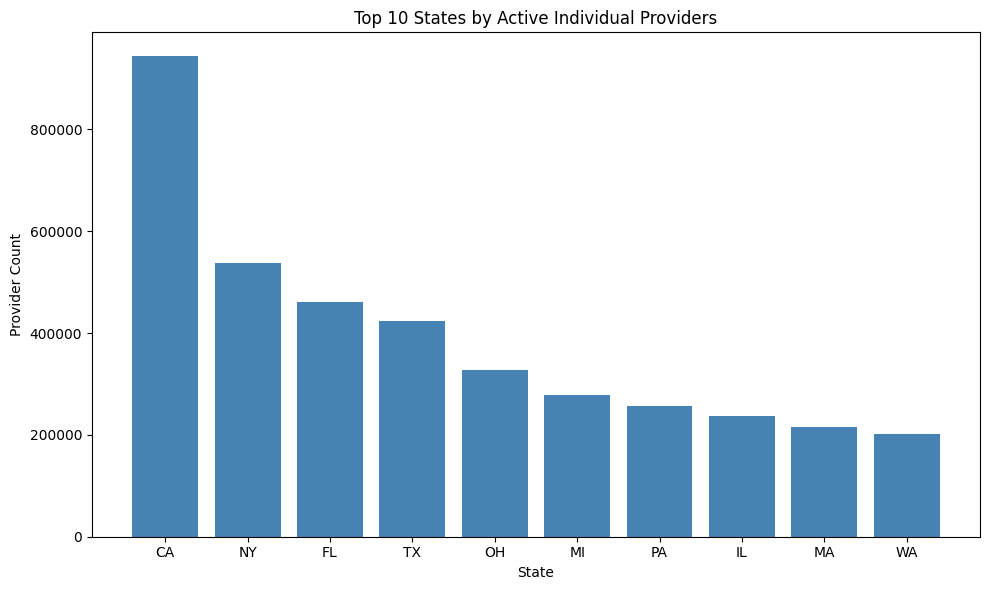

In [9]:
import matplotlib.pyplot as plt

state_counts = npi_filtered[npi_filtered['state'].notna()] \
    .groupby('state')['NPI'] \
    .count() \
    .reset_index() \
    .rename(columns={'NPI': 'provider_count'}) \
    .sort_values('provider_count', ascending=False) \
    .head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(state_counts['state'], state_counts['provider_count'], color='steelblue', edgecolor='none')
ax.set_xlabel('State')
ax.set_ylabel('Provider Count')
ax.set_title('Top 10 States by Active Individual Providers')
plt.tight_layout()
plt.show()

In [10]:
claims_overview = client.query("""
    SELECT
        COUNT(*) as total_rows,
        COUNT(DISTINCT BILLING_PROVIDER_NPI_NUM) as unique_billing_npis,
        COUNT(DISTINCT HCPCS_CODE) as unique_hcpcs_codes,
        MIN(CLAIM_FROM_MONTH) as earliest_month,
        MAX(CLAIM_FROM_MONTH) as latest_month,
        ROUND(SUM(TOTAL_PAID) / 1e9, 2) as total_spend_billions,
        ROUND(AVG(TOTAL_PAID), 2) as avg_paid_per_row
    FROM `medicaid-claims.medicaid_tmsis.provider_claims`
""").to_dataframe()

claims_overview.head()

,total_rows,unique_billing_npis,unique_hcpcs_codes,earliest_month,latest_month,total_spend_billions,avg_paid_per_row
0,227083361,617503,10881,2018-01,2024-12,1093.56,4815.69


In [11]:
unique_npis = client.query("""
    SELECT DISTINCT BILLING_PROVIDER_NPI_NUM
    FROM `medicaid-claims.medicaid_tmsis.provider_claims`
""").to_dataframe()

print(f'Total unique billing NPIs: {len(unique_npis):,}')
print(unique_npis.head())

Total unique billing NPIs: 617,503
  BILLING_PROVIDER_NPI_NUM
0               1982643003
1               1669895199
2               1881642239
3               1518058379
4               1467611855


In [12]:
matched = unique_npis[unique_npis['BILLING_PROVIDER_NPI_NUM'].isin(npi_filtered['NPI'])]
print(f'Unique billing NPIs in claims: {len(unique_npis):,}')
print(f'Matched to npi_filtered (type 1, active): {len(matched):,}')
print(f'Unmatched: {len(unique_npis) - len(matched):,}')
print(f'Match rate: {len(matched) / len(unique_npis) * 100:.1f}%')

Unique billing NPIs in claims: 617,503
Matched to npi_filtered (type 1, active): 267,468
Unmatched: 350,035
Match rate: 43.3%


In [13]:
unique_servicing_npis = client.query("""
    SELECT DISTINCT SERVICING_PROVIDER_NPI_NUM
    FROM `medicaid-claims.medicaid_tmsis.provider_claims`
""").to_dataframe()

print(f'Total unique servicing NPIs: {len(unique_servicing_npis):,}')

Total unique servicing NPIs: 1,627,363


In [14]:
matched_servicing = unique_servicing_npis[unique_servicing_npis['SERVICING_PROVIDER_NPI_NUM'].isin(npi_filtered['NPI'])]
print(f'Unique servicing NPIs in claims: {len(unique_npis):,}')
print(f'Matched to npi_filtered (type 1, active): {len(matched_servicing):,}')
print(f'Unmatched: {len(unique_servicing_npis) - len(matched_servicing):,}')
print(f'Match rate: {len(matched_servicing) / len(unique_servicing_npis) * 100:.1f}%')

Unique servicing NPIs in claims: 617,503
Matched to npi_filtered (type 1, active): 1,429,249
Unmatched: 198,114
Match rate: 87.8%


In [15]:
# get the unmatched billing NPIs
unmatched_npis = unique_npis[~unique_npis['BILLING_PROVIDER_NPI_NUM'].isin(npi_filtered['NPI'])]['BILLING_PROVIDER_NPI_NUM']

# check against full NPI table (before type 1 / active filter)
npi_full = client.query("""
    SELECT NPI, entity_type, deactivation_date
    FROM `medicaid-claims.medicaid_tmsis.npi_entity_types`
""").to_dataframe()

unmatched_diagnosed = unmatched_npis.to_frame().merge(
    npi_full, left_on='BILLING_PROVIDER_NPI_NUM', right_on='NPI', how='left'
)

print(unmatched_diagnosed['entity_type'].value_counts(dropna=False))
print()
print(f"Deactivated: {unmatched_diagnosed['deactivation_date'].notna().sum():,}")
print(f"Not in NPPES at all: {unmatched_diagnosed['NPI'].isna().sum():,}")

entity_type
2       338419
None      8795
NaN       2821
Name: count, dtype: int64

Deactivated: 9,599
Not in NPPES at all: 2,821


In [16]:
valid_billing_npis = matched['BILLING_PROVIDER_NPI_NUM'].tolist()
print(f'Clean analysis population: {len(valid_billing_npis):,}')

# ghost NPIs — not in NPPES at all (worth flagging separately in paper)
ghost_npis = unmatched_diagnosed[unmatched_diagnosed['NPI'].isna()]['BILLING_PROVIDER_NPI_NUM'].tolist()
print(f'Ghost NPIs (not in NPPES): {len(ghost_npis):,}')

# deactivated type 1 — billed then deactivated
deactivated_billers = unmatched_diagnosed[
    (unmatched_diagnosed['entity_type'] == '1') &
    (unmatched_diagnosed['deactivation_date'].notna())
]['BILLING_PROVIDER_NPI_NUM'].tolist()
print(f'Deactivated type 1 billers: {len(deactivated_billers):,}')

Clean analysis population: 267,468
Ghost NPIs (not in NPPES): 2,821
Deactivated type 1 billers: 0


In [17]:
claims.head()

,BILLING_PROVIDER_NPI_NUM,SERVICING_PROVIDER_NPI_NUM,HCPCS_CODE,CLAIM_FROM_MONTH,TOTAL_UNIQUE_BENEFICIARIES,TOTAL_CLAIMS,TOTAL_PAID
0,1134286248,1083876726,90700,2018-01,12,12,217.69
1,1396714663,1477913218,80053,2018-01,12,12,217.31
2,1912397936,nan,T4524,2018-01,12,12,1204.55
3,1922367192,1255779609,D1208,2018-01,12,12,217.47
4,1093263717,1932157369,93306,2018-01,12,12,357.24


In [18]:
claims_filtered = client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.claims_filtered` AS

    SELECT
        c.BILLING_PROVIDER_NPI_NUM,
        c.SERVICING_PROVIDER_NPI_NUM,
        c.HCPCS_CODE,
        c.CLAIM_FROM_MONTH,
        c.TOTAL_UNIQUE_BENEFICIARIES,
        c.TOTAL_CLAIMS,
        c.TOTAL_PAID,
        n.sex_code,
        n.taxonomy_code,
        n.primary_taxonomy_switch,
        n.is_sole_proprietor,
        n.state,
        n.zip,
        LEFT(n.taxonomy_code, 4) AS taxonomy_group,
        CASE
            WHEN c.BILLING_PROVIDER_NPI_NUM != c.SERVICING_PROVIDER_NPI_NUM
            THEN 1 ELSE 0
        END AS billing_servicing_mismatch

    FROM `medicaid-claims.medicaid_tmsis.provider_claims` c
    INNER JOIN `medicaid-claims.medicaid_tmsis.npi_entity_types` n
        ON c.SERVICING_PROVIDER_NPI_NUM = n.NPI
    WHERE n.entity_type = '1'
      AND c.SERVICING_PROVIDER_NPI_NUM IS NOT NULL
      AND (
            n.deactivation_date IS NULL
            OR n.reactivation_date >= n.deactivation_date
          )
""")

claims_filtered.result()
print("Table created successfully")

summary = client.query("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT BILLING_PROVIDER_NPI_NUM) AS unique_billing_npis,
        COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM) AS unique_servicing_npis,
        COUNT(DISTINCT HCPCS_CODE) AS unique_hcpcs,
        COUNT(DISTINCT state) AS unique_states,
        MIN(CLAIM_FROM_MONTH) AS earliest_month,
        MAX(CLAIM_FROM_MONTH) AS latest_month,
        SUM(TOTAL_PAID) AS total_paid_all,
        AVG(TOTAL_PAID) AS avg_paid_per_record,
        SUM(billing_servicing_mismatch) / COUNT(*) AS pct_billing_servicing_mismatch
    FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
""").to_dataframe()

print(summary.T)

Table created successfully
                                                  0
total_rows                                161705943
unique_billing_npis                          474982
unique_servicing_npis                       1428773
unique_hcpcs                                   7984
unique_states                                   166
earliest_month                              2018-01
latest_month                                2024-12
total_paid_all                  300195583872.286316
avg_paid_per_record                     1856.428888
pct_billing_servicing_mismatch             0.880328


TOTAL_PAID could include:
├── FFS claims          ← what you want for fraud detection
├── Managed care encounters  ← acceptable, represents actual services
├── Capitation records  ← dangerous, not provider-level billing
├── Supplemental payments  ← dangerous, inflates legitimate providers
└── DSH/UPL payments    ← dangerous, lump sums not tied to services

In [19]:
states = client.query("""
    SELECT
        state,
        COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM) as providers,
        COUNT(*) as records
    FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
    GROUP BY state
    ORDER BY providers DESC
""").to_dataframe()

states.head(167)

,state,providers,records
0,CA,132075,21773885
1,OH,99214,10383467
2,NY,95441,12490811
3,FL,73742,8035160
4,TX,70959,8695828
...,...,...,...
162,ABU DHABI,1,29
163,ISRAEL,1,11
164,ALAJUELA,1,98
165,TE,1,114


In [20]:
valid_states_query = """
CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.claims_filtered` AS
SELECT *
FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
WHERE state IN (
    'AL','AK','AZ','AR','CA','CO','CT','DE','DC','FL','GA','HI','ID','IL',
    'IN','IA','KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE',
    'NV','NH','NJ','NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD',
    'TN','TX','UT','VT','VA','WA','WV','WI','WY','PR'
)
"""
client.query(valid_states_query).result()
print("State field cleaned")

State field cleaned


In [21]:
bounds_check = client.query("""
    SELECT
        MIN(TOTAL_CLAIMS) AS min_claims,
        MAX(TOTAL_CLAIMS) AS max_claims,
        MIN(TOTAL_UNIQUE_BENEFICIARIES) AS min_benes,
        MAX(TOTAL_UNIQUE_BENEFICIARIES) AS max_benes
    FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
""").to_dataframe()

print(bounds_check)

   min_claims  max_claims  min_benes  max_benes
0          12      118128         12      51331


In [3]:
outlier_check = client.query("""
    SELECT
        BILLING_PROVIDER_NPI_NUM,
        HCPCS_CODE,
        CLAIM_FROM_MONTH,
        TOTAL_CLAIMS,
        TOTAL_UNIQUE_BENEFICIARIES,
        TOTAL_PAID,
        taxonomy_group,
        state
    FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
    WHERE TOTAL_CLAIMS > 10000
       OR TOTAL_UNIQUE_BENEFICIARIES > 5000
    ORDER BY TOTAL_CLAIMS DESC
    LIMIT 50
""").to_dataframe()

outlier_check.head(51)

,BILLING_PROVIDER_NPI_NUM,HCPCS_CODE,CLAIM_FROM_MONTH,TOTAL_CLAIMS,TOTAL_UNIQUE_BENEFICIARIES,TOTAL_PAID,taxonomy_group,state
0,1023613403,91300,2021-04,118128,48061,0.27,207V,IN
1,1023613403,91300,2021-03,98972,31383,0.13,207V,IN
2,1487637724,H0020,2021-03,94954,684,261483.75,207Q,RI
3,1487637724,H0020,2021-02,88928,676,239140.00,207Q,RI
4,1023613403,91300,2021-05,80375,37114,0.18,207V,IN
5,1275665457,U0003,2023-04,79103,15286,5927610.00,207Q,NY
6,1275665457,99211,2023-04,79094,15287,2037358.29,207Q,NY
7,1275665457,U0005,2023-04,79093,15284,1974502.50,207Q,NY
8,1205340502,99211,2022-03,77990,31094,237945.94,363A,NY
9,1023613403,0001A,2021-03,73610,27706,265173.18,207V,IN


In [4]:
len(outlier_check)

50

None of these providers are located in states flagged for having unusable billing data:
https://www.medicaid.gov/dq-atlas/landing/topics/single/map?topic=g15m72&tafVersionId=51

NPI 1801954474
Dr. Eric Lund billed 42256 claims for 97153 in one month in 2023.
CPT code 97153 refers to Adaptive Behavior Treatment by Protocol, a core billing code in Applied Behavior Analysis (ABA) therapy. It covers one-on-one, in-person direct therapy administered by a technician (like an RBT) under the supervision of a BCBA, focusing on skill acquisition and behavior reduction. It is billed in 15-minute units.
42256/30/4
That is the equivalent of 352 hours of practice per day.

https://www.ratemds.com/doctor-ratings/3620111/Dr-ERIC+J.-LUND-GREEN+BAY-WI.html/

NPI 1073629069
1073629069 billed U0003 for ~39k claims in a single month against ~10k unique benes — that's nearly 4 tests per beneficiary per month, for 10 thousand people.
TOTAL_PAID for a single month hits $2.2M for one provider on one code.
This is most certainly billing fraud carried out by Dr. KAREN E THORNTON, MD.

NPI 1144310087
Dr. Michael A Rollin, FNP, NP similarly is billing for covid tests at an astounding rate, claiming he is providing nearly 5 covid tests for 10 thousand people across 6 months in 2022 and 2023.

In [5]:
# Step 1: Build per-year peer stats table (long format)
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.peer_stats_by_year` AS
    SELECT
        LEFT(CLAIM_FROM_MONTH, 4) AS claim_year,
        taxonomy_group,
        state,
        HCPCS_CODE,
        APPROX_QUANTILES(TOTAL_CLAIMS, 4)[OFFSET(2)] AS peer_median_claims_yr,
        APPROX_QUANTILES(TOTAL_CLAIMS, 4)[OFFSET(3)]
            - APPROX_QUANTILES(TOTAL_CLAIMS, 4)[OFFSET(1)] AS peer_iqr_claims_yr,
        APPROX_QUANTILES(TOTAL_UNIQUE_BENEFICIARIES, 4)[OFFSET(2)] AS peer_median_benes_yr,
        APPROX_QUANTILES(TOTAL_UNIQUE_BENEFICIARIES, 4)[OFFSET(3)]
            - APPROX_QUANTILES(TOTAL_UNIQUE_BENEFICIARIES, 4)[OFFSET(1)] AS peer_iqr_benes_yr,
        APPROX_QUANTILES(TOTAL_PAID, 4)[OFFSET(2)] AS peer_median_paid_yr,
        APPROX_QUANTILES(TOTAL_PAID, 4)[OFFSET(3)]
            - APPROX_QUANTILES(TOTAL_PAID, 4)[OFFSET(1)] AS peer_iqr_paid_yr,
        COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM) AS peer_provider_count_yr
    FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
    GROUP BY claim_year, taxonomy_group, state, HCPCS_CODE
""").result()
print("Per-year peer stats table built")

# Step 2: Build cross-year (pooled) peer stats table
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.peer_stats_all_years` AS
    SELECT
        taxonomy_group,
        state,
        HCPCS_CODE,
        APPROX_QUANTILES(TOTAL_CLAIMS, 4)[OFFSET(2)] AS peer_median_claims_all,
        APPROX_QUANTILES(TOTAL_CLAIMS, 4)[OFFSET(3)]
            - APPROX_QUANTILES(TOTAL_CLAIMS, 4)[OFFSET(1)] AS peer_iqr_claims_all,
        APPROX_QUANTILES(TOTAL_UNIQUE_BENEFICIARIES, 4)[OFFSET(2)] AS peer_median_benes_all,
        APPROX_QUANTILES(TOTAL_UNIQUE_BENEFICIARIES, 4)[OFFSET(3)]
            - APPROX_QUANTILES(TOTAL_UNIQUE_BENEFICIARIES, 4)[OFFSET(1)] AS peer_iqr_benes_all,
        APPROX_QUANTILES(TOTAL_PAID, 4)[OFFSET(2)] AS peer_median_paid_all,
        APPROX_QUANTILES(TOTAL_PAID, 4)[OFFSET(3)]
            - APPROX_QUANTILES(TOTAL_PAID, 4)[OFFSET(1)] AS peer_iqr_paid_all,
        COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM) AS peer_provider_count_all
    FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
    GROUP BY taxonomy_group, state, HCPCS_CODE
""").result()
print("Cross-year peer stats table built")

# Step 3: Join peer stats back onto claims
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.claims_peer_scored` AS
    SELECT
        cf.*,
        LEFT(cf.CLAIM_FROM_MONTH, 4) AS claim_year,

        -- Within-year peer stats (for this row's year)
        py.peer_median_claims_yr,
        py.peer_iqr_claims_yr,
        py.peer_median_benes_yr,
        py.peer_iqr_benes_yr,
        py.peer_median_paid_yr,
        py.peer_iqr_paid_yr,
        py.peer_provider_count_yr,
        CASE
            WHEN py.peer_provider_count_yr >= 30 THEN 'high'
            WHEN py.peer_provider_count_yr >= 15 THEN 'medium'
            WHEN py.peer_provider_count_yr >= 5  THEN 'low'
            ELSE 'exclude'
        END AS peer_confidence_yr,

        -- Cross-year (pooled) peer stats
        pa.peer_median_claims_all,
        pa.peer_iqr_claims_all,
        pa.peer_median_benes_all,
        pa.peer_iqr_benes_all,
        pa.peer_median_paid_all,
        pa.peer_iqr_paid_all,
        pa.peer_provider_count_all,
        CASE
            WHEN pa.peer_provider_count_all >= 30 THEN 'high'
            WHEN pa.peer_provider_count_all >= 15 THEN 'medium'
            WHEN pa.peer_provider_count_all >= 5  THEN 'low'
            ELSE 'exclude'
        END AS peer_confidence_all

    FROM `medicaid-claims.medicaid_tmsis.claims_filtered` cf
    LEFT JOIN `medicaid-claims.medicaid_tmsis.peer_stats_by_year` py
        ON LEFT(cf.CLAIM_FROM_MONTH, 4) = py.claim_year
        AND cf.taxonomy_group = py.taxonomy_group
        AND cf.state = py.state
        AND cf.HCPCS_CODE = py.HCPCS_CODE
    LEFT JOIN `medicaid-claims.medicaid_tmsis.peer_stats_all_years` pa
        ON cf.taxonomy_group = pa.taxonomy_group
        AND cf.state = pa.state
        AND cf.HCPCS_CODE = pa.HCPCS_CODE
""").result()
print("Scored claims table built")

# Step 4: Summary for sanity checks
summary = client.query("""
    SELECT
        claim_year,
        COUNT(*) AS total_rows,
        SUM(CASE WHEN peer_confidence_yr  = 'high'   THEN 1 ELSE 0 END) AS yr_high,
        SUM(CASE WHEN peer_confidence_yr  = 'medium' THEN 1 ELSE 0 END) AS yr_medium,
        SUM(CASE WHEN peer_confidence_yr  = 'low'    THEN 1 ELSE 0 END) AS yr_low,
        SUM(CASE WHEN peer_confidence_yr  = 'exclude' THEN 1 ELSE 0 END) AS yr_exclude,
        SUM(CASE WHEN peer_confidence_all = 'high'   THEN 1 ELSE 0 END) AS all_high,
        SUM(CASE WHEN peer_confidence_all = 'exclude' THEN 1 ELSE 0 END) AS all_exclude
    FROM `medicaid-claims.medicaid_tmsis.claims_peer_scored`
    GROUP BY claim_year
    ORDER BY claim_year
""").to_dataframe()

print(summary)

Per-year peer stats table built
Cross-year peer stats table built
Scored claims table built
  claim_year  total_rows   yr_high  yr_medium   yr_low  yr_exclude  all_high  \
0       2018    18026473  14315220    1214590  1309355     1187308  15864099   
1       2019    20154106  16172163    1309002  1406876     1266065  17819413   
2       2020    18902376  15149657    1231299  1322033     1199387  16721880   
3       2021    24831486  20234223    1528035  1629461     1439767  22026796   
4       2022    26807526  21980359    1630477  1710129     1486561  23795880   
5       2023    28232595  23280737    1679900  1757151     1514807  25021681   
6       2024    24642196  20266928    1479602  1559018     1336648  21890905   

   all_exclude  
0       636910  
1       680743  
2       635993  
3       804362  
4       851677  
5       906344  
6       771390  


In [9]:
investigate_2024 = client.query("""
    SELECT LEFT(CLAIM_FROM_MONTH, 7) AS month, COUNT(*) AS row_count
    FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
    WHERE LEFT(CLAIM_FROM_MONTH, 4) = '2024'
    GROUP BY month
    ORDER BY month
""").to_dataframe()
investigate_2024

,month,row_count
0,2024-01,2373180
1,2024-02,2336514
2,2024-03,2300854
3,2024-04,2332615
4,2024-05,2286541
5,2024-06,2009494
6,2024-07,2125781
7,2024-08,2212771
8,2024-09,2098349
9,2024-10,2224266


2024 has weak data for December 2024 and November 2024 likely due to T-MSIS reporting lag. These months were excluded from analysis

In [10]:
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.claims_filtered` AS
    SELECT *
    FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
    WHERE LEFT(CLAIM_FROM_MONTH, 7) NOT IN ('2024-11', '2024-12')
""").result()
print("2024-11 and 2024-12 excluded")

2024-11 and 2024-12 excluded


making sure this lag problem is true across all states:

In [13]:
state_lag = client.query("""SELECT state, LEFT(CLAIM_FROM_MONTH, 7) AS month, COUNT(*) AS row_count
FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
WHERE LEFT(CLAIM_FROM_MONTH, 4) = '2024'
  AND state IN ('CA', 'TX', 'NY', 'FL', 'OH')  -- your top 5
GROUP BY state, month
ORDER BY state, month""").to_dataframe()
state_lag

,state,month,row_count
0,CA,2024-01,345552
1,CA,2024-02,331690
2,CA,2024-03,343291
3,CA,2024-04,351054
4,CA,2024-05,349825
5,CA,2024-06,320310
6,CA,2024-07,339484
7,CA,2024-08,350482
8,CA,2024-09,327647
9,CA,2024-10,344824


In [14]:
# Step 2: Rebuild per-year peer stats
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.peer_stats_by_year` AS
    SELECT
        LEFT(CLAIM_FROM_MONTH, 4) AS claim_year,
        taxonomy_group,
        state,
        HCPCS_CODE,
        APPROX_QUANTILES(TOTAL_CLAIMS, 4)[OFFSET(2)] AS peer_median_claims_yr,
        APPROX_QUANTILES(TOTAL_CLAIMS, 4)[OFFSET(3)]
            - APPROX_QUANTILES(TOTAL_CLAIMS, 4)[OFFSET(1)] AS peer_iqr_claims_yr,
        APPROX_QUANTILES(TOTAL_UNIQUE_BENEFICIARIES, 4)[OFFSET(2)] AS peer_median_benes_yr,
        APPROX_QUANTILES(TOTAL_UNIQUE_BENEFICIARIES, 4)[OFFSET(3)]
            - APPROX_QUANTILES(TOTAL_UNIQUE_BENEFICIARIES, 4)[OFFSET(1)] AS peer_iqr_benes_yr,
        APPROX_QUANTILES(TOTAL_PAID, 4)[OFFSET(2)] AS peer_median_paid_yr,
        APPROX_QUANTILES(TOTAL_PAID, 4)[OFFSET(3)]
            - APPROX_QUANTILES(TOTAL_PAID, 4)[OFFSET(1)] AS peer_iqr_paid_yr,
        COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM) AS peer_provider_count_yr
    FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
    GROUP BY claim_year, taxonomy_group, state, HCPCS_CODE
""").result()
print("Per-year peer stats rebuilt")

# Step 3: Rebuild cross-year peer stats
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.peer_stats_all_years` AS
    SELECT
        taxonomy_group,
        state,
        HCPCS_CODE,
        APPROX_QUANTILES(TOTAL_CLAIMS, 4)[OFFSET(2)] AS peer_median_claims_all,
        APPROX_QUANTILES(TOTAL_CLAIMS, 4)[OFFSET(3)]
            - APPROX_QUANTILES(TOTAL_CLAIMS, 4)[OFFSET(1)] AS peer_iqr_claims_all,
        APPROX_QUANTILES(TOTAL_UNIQUE_BENEFICIARIES, 4)[OFFSET(2)] AS peer_median_benes_all,
        APPROX_QUANTILES(TOTAL_UNIQUE_BENEFICIARIES, 4)[OFFSET(3)]
            - APPROX_QUANTILES(TOTAL_UNIQUE_BENEFICIARIES, 4)[OFFSET(1)] AS peer_iqr_benes_all,
        APPROX_QUANTILES(TOTAL_PAID, 4)[OFFSET(2)] AS peer_median_paid_all,
        APPROX_QUANTILES(TOTAL_PAID, 4)[OFFSET(3)]
            - APPROX_QUANTILES(TOTAL_PAID, 4)[OFFSET(1)] AS peer_iqr_paid_all,
        COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM) AS peer_provider_count_all
    FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
    GROUP BY taxonomy_group, state, HCPCS_CODE
""").result()
print("Cross-year peer stats rebuilt")

# Step 4: Rebuild scored claims table
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.claims_peer_scored` AS
    SELECT
        cf.*,
        LEFT(cf.CLAIM_FROM_MONTH, 4) AS claim_year,

        py.peer_median_claims_yr,
        py.peer_iqr_claims_yr,
        py.peer_median_benes_yr,
        py.peer_iqr_benes_yr,
        py.peer_median_paid_yr,
        py.peer_iqr_paid_yr,
        py.peer_provider_count_yr,
        CASE
            WHEN py.peer_provider_count_yr >= 30 THEN 'high'
            WHEN py.peer_provider_count_yr >= 15 THEN 'medium'
            WHEN py.peer_provider_count_yr >= 5  THEN 'low'
            ELSE 'exclude'
        END AS peer_confidence_yr,

        pa.peer_median_claims_all,
        pa.peer_iqr_claims_all,
        pa.peer_median_benes_all,
        pa.peer_iqr_benes_all,
        pa.peer_median_paid_all,
        pa.peer_iqr_paid_all,
        pa.peer_provider_count_all,
        CASE
            WHEN pa.peer_provider_count_all >= 30 THEN 'high'
            WHEN pa.peer_provider_count_all >= 15 THEN 'medium'
            WHEN pa.peer_provider_count_all >= 5  THEN 'low'
            ELSE 'exclude'
        END AS peer_confidence_all

    FROM `medicaid-claims.medicaid_tmsis.claims_filtered` cf
    LEFT JOIN `medicaid-claims.medicaid_tmsis.peer_stats_by_year` py
        ON LEFT(cf.CLAIM_FROM_MONTH, 4) = py.claim_year
        AND cf.taxonomy_group = py.taxonomy_group
        AND cf.state = py.state
        AND cf.HCPCS_CODE = py.HCPCS_CODE
    LEFT JOIN `medicaid-claims.medicaid_tmsis.peer_stats_all_years` pa
        ON cf.taxonomy_group = pa.taxonomy_group
        AND cf.state = pa.state
        AND cf.HCPCS_CODE = pa.HCPCS_CODE
""").result()
print("Scored claims table rebuilt")

Per-year peer stats rebuilt
Cross-year peer stats rebuilt
Scored claims table rebuilt


In [15]:
unscorable_check = client.query("""
    SELECT
        taxonomy_group,
        state,
        COUNT(DISTINCT HCPCS_CODE) AS distinct_codes,
        COUNT(DISTINCT CASE WHEN peer_confidence_all = 'exclude' THEN HCPCS_CODE END) AS unscorable_codes,
        SUM(CASE WHEN peer_confidence_all = 'exclude' THEN 1 ELSE 0 END) AS unscorable_rows,
        SUM(CASE WHEN peer_confidence_yr  = 'exclude' THEN 1 ELSE 0 END) AS unscorable_rows_yr,
        COUNT(*) AS total_rows,
        SAFE_DIVIDE(
            SUM(CASE WHEN peer_confidence_all = 'exclude' THEN 1 ELSE 0 END),
            COUNT(*)
        ) AS pct_unscorable
    FROM `medicaid-claims.medicaid_tmsis.claims_peer_scored`
    GROUP BY taxonomy_group, state
    HAVING unscorable_rows > 0
    ORDER BY unscorable_rows DESC
    LIMIT 20
""").to_dataframe()

print(unscorable_check)

   taxonomy_group state  distinct_codes  unscorable_codes  unscorable_rows  \
0            1744    IL             691               613            29137   
1            1744    CA            1810              1161            26963   
2            1744    NY            1233               820            23513   
3            207R    CA            2444              1247            20028   
4            207R    NY            2001              1080            20007   
5            207Z    MD             434               388            17357   
6            207Z    NY             584               484            16225   
7            2080    CA            1609               835            15809   
8            1744    LA             871               650            15048   
9            1744    TN             838               583            14704   
10           3902    CA            1799               993            14440   
11           1744    TX             793               588       

In [16]:
malformed_taxonomy = client.query("""SELECT taxonomy_code, COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM) AS providers
   FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
   WHERE taxonomy_group = '1744'
   GROUP BY taxonomy_code
   ORDER BY providers DESC
   LIMIT 20""").to_dataframe()

malformed_taxonomy

,taxonomy_code,providers
0,174400000X,11289
1,1744R1102X,15
2,1744P3200X,5
3,1744G0900X,2
4,1744R1103X,1


In [17]:
generic_taxonomy = client.query("""
    SELECT
    taxonomy_group,
    COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM) AS providers,
    COUNT(*) AS rows_
FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
GROUP BY taxonomy_group
ORDER BY providers DESC
LIMIT 30""").to_dataframe()

generic_taxonomy

,taxonomy_group,providers,rows_
0,363L,183994,15948563
1,207R,158863,16461875
2,101Y,89155,2758778
3,207Q,85346,12352990
4,1223,72784,20758520
5,363A,72470,5525217
6,2080,69402,20377815
7,1041,56564,1761426
8,207P,51154,13298004
9,3902,45293,4952172


In [18]:
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.claims_peer_scored` AS
    SELECT
        *,
        taxonomy_group IN ('1744', '3902') AS generic_taxonomy_flag
    FROM `medicaid-claims.medicaid_tmsis.claims_peer_scored`
""").result()

Phase 1 Summary

1. Decided on the analytic grain: servicing NPI, not billing NPI
We talked through the tradeoff. Billing NPI (the entity receiving payment) aggregates multiple specialties for group practices, which muddies peer comparison. Servicing NPI (the individual who actually performed the service) gives you clean taxonomy alignment. You kept billing NPI available as a future feature source (for organizational fraud patterns like shell clinics and billing-entity churn) but made servicing NPI the unit of analysis.
2. Built claims_filtered
Started from provider_claims and joined to npi_entity_types on servicing NPI. Filtered to entity_type='1' (individuals only — since servicing providers should be people, not organizations) and to currently-active providers (handling NPPES's deactivation/reactivation dates correctly). Also added a billing_servicing_mismatch flag for future use.
3. Ran summary stats and caught two data quality issues
The summary on claims_filtered returned 162M rows, 1.43M unique servicing NPIs, 475K billing NPIs — all sensible scales. But two red flags surfaced:

166 unique "states" when there should be ~52. The long tail was NPPES free-text contamination (full state names, foreign addresses, typos, military codes).
An 88% billing≠servicing rate, which is high but plausible for group-practice-dominant Medicaid.

4. Cleaned the state field
Filtered claims_filtered to only the 52 valid US codes (50 states + DC + PR). Dropped ~100K garbage rows out of 162M — negligible volume loss, big gain in peer grouping reliability.
5. Identified T-MSIS reporting lag in late 2024
Built and ran the peer stats pipeline once, then noticed 2024 had lower row counts than expected. Investigated month-by-month: Jan–Oct 2024 was fine, Nov was at 75% of baseline, Dec was at 27%. Classic T-MSIS reporting lag — states submit on a delay, recent months undercount.
Also checked whether the lag was state-uniform (to rule out peer-group bias). It was: top 5 states all showed the same shape. So you dropped Nov+Dec 2024 from claims_filtered and kept everything else. No state exclusion needed.
6. Built the peer statistics infrastructure
Three tables, each aligned to the taxonomy_group × state × HCPCS_CODE peer definition:

peer_stats_by_year — one row per (year, taxonomy, state, HCPCS). Stores median and IQR for TOTAL_CLAIMS, TOTAL_UNIQUE_BENEFICIARIES, TOTAL_PAID, plus the count of distinct servicing providers in that peer group. Used APPROX_QUANTILES for efficiency over PERCENTILE_CONT.
peer_stats_all_years — same structure but pooled across all years. One stable long-term baseline per (taxonomy, state, HCPCS) cell.
claims_peer_scored — the 162M-row claims table joined to both stats tables. Each row now carries its own billing metrics plus (a) the within-year peer stats for its year, (b) the cross-year peer stats, and (c) two confidence tiers (peer_confidence_yr and peer_confidence_all) based on peer group size: high (≥30 providers), medium (≥15), low (≥5), exclude (<5).

7. Decided to drop is_sole_proprietor from the peer definition
Earlier pipeline drafts had it as a partition key. We agreed it should be a downstream feature instead — partitioning on it fragmented peer groups in half without strong evidence it was needed.
8. Validated confidence tier coverage
Summary by year showed ~80% of rows hitting yr_high and ~88% hitting all_high, consistent across all years. No year is structurally weaker than any other. The cross-year pooled stats recover more peer groups than within-year, as expected — which means rare-HCPCS rows lean on the cross-year signal.
9. Investigated where unscorable rows concentrate
Ran a diagnostic grouping unscorable rows by taxonomy × state. Two patterns emerged:

Pathology (207Z) — structurally high unscorable rate due to the huge number of rare test-specific HCPCS codes. Known limitation; no fix.
Taxonomy 1744 — turned out to be the NUCC code for "Specialist," a generic catch-all bucket. Providers here do wildly different work, so peer comparison is fundamentally incoherent. Also looked at top 30 taxonomies and found 3902 ("Student, Health Care") has a similar catch-all quality.

10. Decided: leave the unscorable rows alone
Option D. The pipeline is already correctly flagging these as unscorable via the confidence tiers. You're not losing signal, you're correctly identifying that there is no signal to be had for these cells. No code changes needed.
Where you are now
Your claims_peer_scored table contains every claim row from Jan 2018 through Oct 2024, filtered to individual providers in valid US states, enriched with within-year and cross-year peer statistics, and tagged with confidence tiers. The reference infrastructure is done.

In [19]:
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.claims_deviation_scored` AS
    SELECT
        *,
        -- Within-year deviation scores
        SAFE_DIVIDE(TOTAL_CLAIMS             - peer_median_claims_yr, peer_iqr_claims_yr) AS dev_claims_yr,
        SAFE_DIVIDE(TOTAL_UNIQUE_BENEFICIARIES - peer_median_benes_yr, peer_iqr_benes_yr)  AS dev_benes_yr,
        SAFE_DIVIDE(TOTAL_PAID               - peer_median_paid_yr,   peer_iqr_paid_yr)   AS dev_paid_yr,

        -- Cross-year deviation scores
        SAFE_DIVIDE(TOTAL_CLAIMS             - peer_median_claims_all, peer_iqr_claims_all) AS dev_claims_all,
        SAFE_DIVIDE(TOTAL_UNIQUE_BENEFICIARIES - peer_median_benes_all, peer_iqr_benes_all)  AS dev_benes_all,
        SAFE_DIVIDE(TOTAL_PAID               - peer_median_paid_all,   peer_iqr_paid_all)   AS dev_paid_all

    FROM `medicaid-claims.medicaid_tmsis.claims_peer_scored`
""").result()
print("Deviation-scored table built")

Deviation-scored table built


In [22]:
client.query("""
    SELECT
        APPROX_QUANTILES(dev_paid_yr, 100)[OFFSET(50)] AS p50,
        APPROX_QUANTILES(dev_paid_yr, 100)[OFFSET(90)] AS p90,
        APPROX_QUANTILES(dev_paid_yr, 100)[OFFSET(99)] AS p99,
        APPROX_QUANTILES(dev_paid_yr, 100)[OFFSET(100)] AS max_val,
        COUNTIF(dev_paid_yr IS NULL) AS null_count,
        COUNT(*) AS total
    FROM `medicaid-claims.medicaid_tmsis.claims_deviation_scored`
    WHERE peer_confidence_yr IN ('high', 'medium')
""").to_dataframe()

,p50,p90,p99,max_val,null_count,total
0,0.0,1.758442,7.883435,3482736.0,11070748,139335349


In [23]:
client.query("""
    SELECT
        APPROX_QUANTILES(dev_paid_yr, 1000)[OFFSET(990)]  AS p99_0,
        APPROX_QUANTILES(dev_paid_yr, 1000)[OFFSET(999)]  AS p99_9,
        APPROX_QUANTILES(dev_paid_yr, 10000)[OFFSET(9999)] AS p99_99,
        COUNTIF(dev_paid_yr > 10)   AS count_gt_10,
        COUNTIF(dev_paid_yr > 50)   AS count_gt_50,
        COUNTIF(dev_paid_yr > 100)  AS count_gt_100,
        COUNTIF(dev_paid_yr > 1000) AS count_gt_1000
    FROM `medicaid-claims.medicaid_tmsis.claims_deviation_scored`
    WHERE peer_confidence_yr IN ('high', 'medium')
""").to_dataframe()

,p99_0,p99_9,p99_99,count_gt_10,count_gt_50,count_gt_100,count_gt_1000
0,7.908723,49.671276,7260.0,880042,126858,78137,32369


In [24]:
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.provider_anomaly_scores` AS

    WITH row_flags AS (
        SELECT
            SERVICING_PROVIDER_NPI_NUM,
            claim_year,
            HCPCS_CODE,
            TOTAL_PAID,
            -- Directional anomaly, threshold 10, trustworthy peer groups only
            CASE
                WHEN peer_confidence_yr IN ('high', 'medium')
                 AND dev_paid_yr > 10
                THEN 1 ELSE 0
            END AS is_anomalous_yr,
            CASE
                WHEN peer_confidence_all IN ('high', 'medium')
                 AND dev_paid_all > 10
                THEN 1 ELSE 0
            END AS is_anomalous_all
        FROM `medicaid-claims.medicaid_tmsis.claims_deviation_scored`
    ),

    per_year_rollup AS (
        SELECT
            SERVICING_PROVIDER_NPI_NUM,
            claim_year,
            COUNT(DISTINCT CASE WHEN is_anomalous_yr = 1 THEN HCPCS_CODE END) AS anomalous_codes_yr,
            SUM(CASE WHEN is_anomalous_yr = 1 THEN TOTAL_PAID ELSE 0 END)     AS anomalous_paid_yr,
            COUNT(DISTINCT HCPCS_CODE)                                         AS total_codes_yr,
            SUM(TOTAL_PAID)                                                    AS total_paid_yr
        FROM row_flags
        GROUP BY SERVICING_PROVIDER_NPI_NUM, claim_year
    ),

    pooled_rollup AS (
        SELECT
            SERVICING_PROVIDER_NPI_NUM,
            COUNT(DISTINCT CASE WHEN is_anomalous_all = 1 THEN HCPCS_CODE END) AS anomalous_codes_all,
            SUM(CASE WHEN is_anomalous_all = 1 THEN TOTAL_PAID ELSE 0 END)     AS anomalous_paid_all,
            COUNT(DISTINCT HCPCS_CODE)                                          AS total_codes_all,
            SUM(TOTAL_PAID)                                                     AS total_paid_all
        FROM row_flags
        GROUP BY SERVICING_PROVIDER_NPI_NUM
    )

    SELECT
        py.SERVICING_PROVIDER_NPI_NUM,
        py.claim_year,
        py.anomalous_codes_yr,
        py.anomalous_paid_yr,
        py.total_codes_yr,
        py.total_paid_yr,
        py.anomalous_codes_yr * LN(1 + py.anomalous_paid_yr) AS anomaly_score_yr,

        pl.anomalous_codes_all,
        pl.anomalous_paid_all,
        pl.total_codes_all,
        pl.total_paid_all,
        pl.anomalous_codes_all * LN(1 + pl.anomalous_paid_all) AS anomaly_score_all
    FROM per_year_rollup py
    LEFT JOIN pooled_rollup pl
        USING (SERVICING_PROVIDER_NPI_NUM)
""").result()
print("Provider anomaly scores table built")

Provider anomaly scores table built


In [25]:
client.query("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT CONCAT(CAST(SERVICING_PROVIDER_NPI_NUM AS STRING), '|', claim_year)) AS unique_npi_year_pairs,
        COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM) AS unique_npis,
        COUNT(DISTINCT claim_year) AS unique_years
    FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores`
""").to_dataframe()

,total_rows,unique_npi_year_pairs,unique_npis,unique_years
0,5491872,5491872,1421339,7



Each provider has between 1 and 7 rows in this table, one per year they had any billing activity. Within each row, anomaly_score_yr reflects their behavior that year vs same-year peers, and anomaly_score_all is their provider-level constant across the 7-year pooled baseline.


In [26]:
client.query("""
    SELECT
        SERVICING_PROVIDER_NPI_NUM,
        COUNT(DISTINCT anomaly_score_all) AS distinct_all_scores,
        COUNT(DISTINCT claim_year) AS years_present
    FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores`
    GROUP BY SERVICING_PROVIDER_NPI_NUM
    HAVING COUNT(DISTINCT claim_year) > 1
    ORDER BY distinct_all_scores DESC
    LIMIT 10
""").to_dataframe()

,SERVICING_PROVIDER_NPI_NUM,distinct_all_scores,years_present
0,1013992635,1,7
1,1336663897,1,7
2,1952715609,1,7
3,1720215361,1,5
4,1386264216,1,2
5,1457589970,1,7
6,1548269640,1,5
7,1265606255,1,7
8,1255317368,1,7
9,1750524856,1,7


In [28]:
client.query("""
    WITH top_providers AS (
        SELECT SERVICING_PROVIDER_NPI_NUM
        FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores`
        WHERE anomaly_score_all IS NOT NULL
        GROUP BY SERVICING_PROVIDER_NPI_NUM
        ORDER BY ANY_VALUE(anomaly_score_all) DESC
        LIMIT 5
    )
    SELECT
        p.SERVICING_PROVIDER_NPI_NUM,
        p.claim_year,
        p.anomalous_codes_yr,
        p.anomalous_paid_yr,
        p.anomaly_score_yr,
        p.anomaly_score_all
    FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores` p
    INNER JOIN top_providers t
        USING (SERVICING_PROVIDER_NPI_NUM)
    ORDER BY SERVICING_PROVIDER_NPI_NUM, claim_year
""").to_dataframe()

,SERVICING_PROVIDER_NPI_NUM,claim_year,anomalous_codes_yr,anomalous_paid_yr,anomaly_score_yr,anomaly_score_all
0,1003894767,2018,15,47237.34,161.444417,939.891474
1,1003894767,2019,23,156430.08,275.088529,939.891474
2,1003894767,2020,34,433409.07,441.300946,939.891474
3,1003894767,2021,33,572639.05,437.514416,939.891474
4,1003894767,2022,11,212137.78,134.914956,939.891474
5,1003894767,2023,11,343277.54,140.209272,939.891474
6,1003894767,2024,6,38614.35,63.368431,939.891474
7,1417968298,2018,8,16227.16,77.556026,836.634481
8,1417968298,2019,26,340127.50,331.164048,836.634481
9,1417968298,2020,33,272013.92,412.949202,836.634481


In [32]:
client.query("""
    SELECT DISTINCT
        cf.SERVICING_PROVIDER_NPI_NUM,
        cf.taxonomy_group,
        cf.state,
        cf.is_sole_proprietor
    FROM `medicaid-claims.medicaid_tmsis.claims_filtered` cf
    WHERE cf.SERVICING_PROVIDER_NPI_NUM IN (
        '1003894767', '1417968298', '1457354656', '1538196944', '1912923020'
    )
""").to_dataframe()

,SERVICING_PROVIDER_NPI_NUM,taxonomy_group,state,is_sole_proprietor
0,1912923020,207Z,FL,N
1,1417968298,207Z,FL,N
2,1457354656,207Z,IL,N
3,1003894767,207Z,FL,Y
4,1538196944,207Z,FL,N


In [34]:
client.query("""
    SELECT
        cf.HCPCS_CODE,
        cf.claim_year,
        cf.TOTAL_PAID,
        cf.peer_median_paid_all,
        cf.dev_paid_all
    FROM `medicaid-claims.medicaid_tmsis.claims_deviation_scored` cf
    WHERE cf.SERVICING_PROVIDER_NPI_NUM = '1457354656'
      AND cf.dev_paid_all > 10
      AND cf.peer_confidence_all IN ('high', 'medium')
    ORDER BY cf.dev_paid_all DESC
    LIMIT 20
""").to_dataframe()

,HCPCS_CODE,claim_year,TOTAL_PAID,peer_median_paid_all,dev_paid_all
0,80076,2018,11869.45,137.74,52.826504
1,85045,2018,2135.50,35.37,48.828877
2,80076,2018,10504.60,137.74,46.680746
3,80076,2018,9917.09,137.74,44.035258
4,80076,2020,9761.72,137.74,43.335645
5,85045,2018,1894.24,35.37,43.219484
6,80076,2019,9712.98,137.74,43.116174
7,80076,2018,9500.91,137.74,42.161248
8,80076,2018,9493.19,137.74,42.126486
9,80076,2020,9325.26,137.74,41.370317


In [35]:
# Price-per-claim peer stats
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.peer_stats_ppc_by_year` AS
    WITH row_ppc AS (
        SELECT
            LEFT(CLAIM_FROM_MONTH, 4) AS claim_year,
            taxonomy_group, state, HCPCS_CODE,
            SAFE_DIVIDE(TOTAL_PAID, TOTAL_CLAIMS) AS paid_per_claim
        FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
        WHERE TOTAL_CLAIMS > 0
    )
    SELECT
        claim_year, taxonomy_group, state, HCPCS_CODE,
        APPROX_QUANTILES(paid_per_claim, 4)[OFFSET(2)] AS peer_median_ppc_yr,
        APPROX_QUANTILES(paid_per_claim, 4)[OFFSET(3)]
            - APPROX_QUANTILES(paid_per_claim, 4)[OFFSET(1)] AS peer_iqr_ppc_yr
    FROM row_ppc
    WHERE paid_per_claim IS NOT NULL
    GROUP BY claim_year, taxonomy_group, state, HCPCS_CODE
""").result()
print("Per-year PPC peer stats built")

client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.peer_stats_ppc_all_years` AS
    WITH row_ppc AS (
        SELECT
            taxonomy_group, state, HCPCS_CODE,
            SAFE_DIVIDE(TOTAL_PAID, TOTAL_CLAIMS) AS paid_per_claim
        FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
        WHERE TOTAL_CLAIMS > 0
    )
    SELECT
        taxonomy_group, state, HCPCS_CODE,
        APPROX_QUANTILES(paid_per_claim, 4)[OFFSET(2)] AS peer_median_ppc_all,
        APPROX_QUANTILES(paid_per_claim, 4)[OFFSET(3)]
            - APPROX_QUANTILES(paid_per_claim, 4)[OFFSET(1)] AS peer_iqr_ppc_all
    FROM row_ppc
    WHERE paid_per_claim IS NOT NULL
    GROUP BY taxonomy_group, state, HCPCS_CODE
""").result()
print("Cross-year PPC peer stats built")

# Intensity (claims-per-beneficiary) peer stats
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.peer_stats_intensity_by_year` AS
    WITH row_intensity AS (
        SELECT
            LEFT(CLAIM_FROM_MONTH, 4) AS claim_year,
            taxonomy_group, state, HCPCS_CODE,
            SAFE_DIVIDE(TOTAL_CLAIMS, TOTAL_UNIQUE_BENEFICIARIES) AS claims_per_bene
        FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
        WHERE TOTAL_UNIQUE_BENEFICIARIES > 0
    )
    SELECT
        claim_year, taxonomy_group, state, HCPCS_CODE,
        APPROX_QUANTILES(claims_per_bene, 4)[OFFSET(2)] AS peer_median_intensity_yr,
        APPROX_QUANTILES(claims_per_bene, 4)[OFFSET(3)]
            - APPROX_QUANTILES(claims_per_bene, 4)[OFFSET(1)] AS peer_iqr_intensity_yr
    FROM row_intensity
    WHERE claims_per_bene IS NOT NULL
    GROUP BY claim_year, taxonomy_group, state, HCPCS_CODE
""").result()
print("Per-year intensity peer stats built")

client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.peer_stats_intensity_all_years` AS
    WITH row_intensity AS (
        SELECT
            taxonomy_group, state, HCPCS_CODE,
            SAFE_DIVIDE(TOTAL_CLAIMS, TOTAL_UNIQUE_BENEFICIARIES) AS claims_per_bene
        FROM `medicaid-claims.medicaid_tmsis.claims_filtered`
        WHERE TOTAL_UNIQUE_BENEFICIARIES > 0
    )
    SELECT
        taxonomy_group, state, HCPCS_CODE,
        APPROX_QUANTILES(claims_per_bene, 4)[OFFSET(2)] AS peer_median_intensity_all,
        APPROX_QUANTILES(claims_per_bene, 4)[OFFSET(3)]
            - APPROX_QUANTILES(claims_per_bene, 4)[OFFSET(1)] AS peer_iqr_intensity_all
    FROM row_intensity
    WHERE claims_per_bene IS NOT NULL
    GROUP BY taxonomy_group, state, HCPCS_CODE
""").result()
print("Cross-year intensity peer stats built")

Per-year PPC peer stats built
Cross-year PPC peer stats built
Per-year intensity peer stats built
Cross-year intensity peer stats built


In [36]:
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.claims_deviation_scored` AS
    SELECT
        cf.*,

        -- Derived metrics
        SAFE_DIVIDE(cf.TOTAL_PAID, cf.TOTAL_CLAIMS) AS paid_per_claim,
        SAFE_DIVIDE(cf.TOTAL_CLAIMS, cf.TOTAL_UNIQUE_BENEFICIARIES) AS claims_per_bene,

        -- Existing within-year deviations (kept for continuity, dev_paid ignored downstream)
        SAFE_DIVIDE(cf.TOTAL_CLAIMS - cf.peer_median_claims_yr, cf.peer_iqr_claims_yr) AS dev_claims_yr,
        SAFE_DIVIDE(cf.TOTAL_UNIQUE_BENEFICIARIES - cf.peer_median_benes_yr, cf.peer_iqr_benes_yr) AS dev_benes_yr,
        SAFE_DIVIDE(cf.TOTAL_PAID - cf.peer_median_paid_yr, cf.peer_iqr_paid_yr) AS dev_paid_yr,

        -- Existing cross-year deviations
        SAFE_DIVIDE(cf.TOTAL_CLAIMS - cf.peer_median_claims_all, cf.peer_iqr_claims_all) AS dev_claims_all,
        SAFE_DIVIDE(cf.TOTAL_UNIQUE_BENEFICIARIES - cf.peer_median_benes_all, cf.peer_iqr_benes_all) AS dev_benes_all,
        SAFE_DIVIDE(cf.TOTAL_PAID - cf.peer_median_paid_all, cf.peer_iqr_paid_all) AS dev_paid_all,

        -- NEW: Price-per-claim deviations
        ppy.peer_median_ppc_yr,
        ppy.peer_iqr_ppc_yr,
        SAFE_DIVIDE(
            SAFE_DIVIDE(cf.TOTAL_PAID, cf.TOTAL_CLAIMS) - ppy.peer_median_ppc_yr,
            ppy.peer_iqr_ppc_yr
        ) AS dev_ppc_yr,

        ppa.peer_median_ppc_all,
        ppa.peer_iqr_ppc_all,
        SAFE_DIVIDE(
            SAFE_DIVIDE(cf.TOTAL_PAID, cf.TOTAL_CLAIMS) - ppa.peer_median_ppc_all,
            ppa.peer_iqr_ppc_all
        ) AS dev_ppc_all,

        -- NEW: Intensity (claims-per-beneficiary) deviations
        ipy.peer_median_intensity_yr,
        ipy.peer_iqr_intensity_yr,
        SAFE_DIVIDE(
            SAFE_DIVIDE(cf.TOTAL_CLAIMS, cf.TOTAL_UNIQUE_BENEFICIARIES) - ipy.peer_median_intensity_yr,
            ipy.peer_iqr_intensity_yr
        ) AS dev_intensity_yr,

        ipa.peer_median_intensity_all,
        ipa.peer_iqr_intensity_all,
        SAFE_DIVIDE(
            SAFE_DIVIDE(cf.TOTAL_CLAIMS, cf.TOTAL_UNIQUE_BENEFICIARIES) - ipa.peer_median_intensity_all,
            ipa.peer_iqr_intensity_all
        ) AS dev_intensity_all

    FROM `medicaid-claims.medicaid_tmsis.claims_peer_scored` cf
    LEFT JOIN `medicaid-claims.medicaid_tmsis.peer_stats_ppc_by_year` ppy
        ON LEFT(cf.CLAIM_FROM_MONTH, 4) = ppy.claim_year
        AND cf.taxonomy_group = ppy.taxonomy_group
        AND cf.state = ppy.state
        AND cf.HCPCS_CODE = ppy.HCPCS_CODE
    LEFT JOIN `medicaid-claims.medicaid_tmsis.peer_stats_ppc_all_years` ppa
        ON cf.taxonomy_group = ppa.taxonomy_group
        AND cf.state = ppa.state
        AND cf.HCPCS_CODE = ppa.HCPCS_CODE
    LEFT JOIN `medicaid-claims.medicaid_tmsis.peer_stats_intensity_by_year` ipy
        ON LEFT(cf.CLAIM_FROM_MONTH, 4) = ipy.claim_year
        AND cf.taxonomy_group = ipy.taxonomy_group
        AND cf.state = ipy.state
        AND cf.HCPCS_CODE = ipy.HCPCS_CODE
    LEFT JOIN `medicaid-claims.medicaid_tmsis.peer_stats_intensity_all_years` ipa
        ON cf.taxonomy_group = ipa.taxonomy_group
        AND cf.state = ipa.state
        AND cf.HCPCS_CODE = ipa.HCPCS_CODE
""").result()
print("Deviation-scored table rebuilt with PPC and intensity signals")

Deviation-scored table rebuilt with PPC and intensity signals


In [37]:
client.query("""
    SELECT
        'dev_ppc_all' AS signal,
        APPROX_QUANTILES(dev_ppc_all, 100)[OFFSET(50)] AS p50,
        APPROX_QUANTILES(dev_ppc_all, 100)[OFFSET(90)] AS p90,
        APPROX_QUANTILES(dev_ppc_all, 100)[OFFSET(99)] AS p99,
        COUNTIF(dev_ppc_all > 10) AS count_gt_10,
        COUNTIF(dev_ppc_all IS NULL) AS null_count
    FROM `medicaid-claims.medicaid_tmsis.claims_deviation_scored`
    WHERE peer_confidence_all IN ('high', 'medium')
    UNION ALL
    SELECT
        'dev_intensity_all',
        APPROX_QUANTILES(dev_intensity_all, 100)[OFFSET(50)],
        APPROX_QUANTILES(dev_intensity_all, 100)[OFFSET(90)],
        APPROX_QUANTILES(dev_intensity_all, 100)[OFFSET(99)],
        COUNTIF(dev_intensity_all > 10),
        COUNTIF(dev_intensity_all IS NULL)
    FROM `medicaid-claims.medicaid_tmsis.claims_deviation_scored`
    WHERE peer_confidence_all IN ('high', 'medium')
    UNION ALL
    SELECT
        'dev_claims_all',
        APPROX_QUANTILES(dev_claims_all, 100)[OFFSET(50)],
        APPROX_QUANTILES(dev_claims_all, 100)[OFFSET(90)],
        APPROX_QUANTILES(dev_claims_all, 100)[OFFSET(99)],
        COUNTIF(dev_claims_all > 10),
        COUNTIF(dev_claims_all IS NULL)
    FROM `medicaid-claims.medicaid_tmsis.claims_deviation_scored`
    WHERE peer_confidence_all IN ('high', 'medium')
""").to_dataframe()

,signal,p50,p90,p99,count_gt_10,null_count
0,dev_intensity_all,0.0,1.809524,8.833333,1108495,14111120
1,dev_ppc_all,0.0,1.147986,7.034461,877723,12062429
2,dev_claims_all,0.0,1.700000,5.967742,433274,0


In [39]:
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.provider_anomaly_scores` AS

    WITH row_flags AS (
        SELECT
            SERVICING_PROVIDER_NPI_NUM,
            claim_year,
            HCPCS_CODE,
            TOTAL_PAID,
            CASE
                WHEN peer_confidence_yr IN ('high', 'medium')
                 AND TOTAL_PAID > 0
                 AND (dev_ppc_yr > 10 OR dev_claims_yr > 10 OR dev_intensity_yr > 10)
                THEN 1 ELSE 0
            END AS is_anomalous_yr,
            CASE
                WHEN peer_confidence_all IN ('high', 'medium')
                 AND TOTAL_PAID > 0
                 AND (dev_ppc_all > 10 OR dev_claims_all > 10 OR dev_intensity_all > 10)
                THEN 1 ELSE 0
            END AS is_anomalous_all
        FROM `medicaid-claims.medicaid_tmsis.claims_deviation_scored`
    ),

    per_year_rollup AS (
        SELECT
            SERVICING_PROVIDER_NPI_NUM,
            claim_year,
            COUNT(DISTINCT CASE WHEN is_anomalous_yr = 1 THEN HCPCS_CODE END) AS anomalous_codes_yr,
            SUM(CASE WHEN is_anomalous_yr = 1 THEN TOTAL_PAID ELSE 0 END)     AS anomalous_paid_yr,
            COUNT(DISTINCT HCPCS_CODE)                                         AS total_codes_yr,
            SUM(TOTAL_PAID)                                                    AS total_paid_yr
        FROM row_flags
        GROUP BY SERVICING_PROVIDER_NPI_NUM, claim_year
    ),

    pooled_rollup AS (
        SELECT
            SERVICING_PROVIDER_NPI_NUM,
            COUNT(DISTINCT CASE WHEN is_anomalous_all = 1 THEN HCPCS_CODE END) AS anomalous_codes_all,
            SUM(CASE WHEN is_anomalous_all = 1 THEN TOTAL_PAID ELSE 0 END)     AS anomalous_paid_all,
            COUNT(DISTINCT HCPCS_CODE)                                          AS total_codes_all,
            SUM(TOTAL_PAID)                                                     AS total_paid_all
        FROM row_flags
        GROUP BY SERVICING_PROVIDER_NPI_NUM
    )

    SELECT
        py.SERVICING_PROVIDER_NPI_NUM,
        py.claim_year,
        py.anomalous_codes_yr,
        py.anomalous_paid_yr,
        py.total_codes_yr,
        py.total_paid_yr,
        py.anomalous_codes_yr * LN(1 + GREATEST(py.anomalous_paid_yr, 0)) AS anomaly_score_yr,

        pl.anomalous_codes_all,
        pl.anomalous_paid_all,
        pl.total_codes_all,
        pl.total_paid_all,
        pl.anomalous_codes_all * LN(1 + GREATEST(pl.anomalous_paid_all, 0)) AS anomaly_score_all
    FROM per_year_rollup py
    LEFT JOIN pooled_rollup pl
        USING (SERVICING_PROVIDER_NPI_NUM)
""").result()
print("Provider anomaly scores rebuilt with three-signal flagging")

Provider anomaly scores rebuilt with three-signal flagging


In [40]:
client.query("""
    WITH top_providers AS (
        SELECT SERVICING_PROVIDER_NPI_NUM
        FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores`
        WHERE anomaly_score_all IS NOT NULL
        GROUP BY SERVICING_PROVIDER_NPI_NUM
        ORDER BY ANY_VALUE(anomaly_score_all) DESC
        LIMIT 5
    )
    SELECT
        p.SERVICING_PROVIDER_NPI_NUM,
        p.claim_year,
        p.anomalous_codes_yr,
        p.anomalous_paid_yr,
        p.anomaly_score_yr,
        p.anomaly_score_all
    FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores` p
    INNER JOIN top_providers t
        USING (SERVICING_PROVIDER_NPI_NUM)
    ORDER BY SERVICING_PROVIDER_NPI_NUM, claim_year
""").to_dataframe()

,SERVICING_PROVIDER_NPI_NUM,claim_year,anomalous_codes_yr,anomalous_paid_yr,anomaly_score_yr,anomaly_score_all
0,1235225558,2018,51,293444.59,642.061823,1009.229129
1,1235225558,2019,35,193129.51,425.989251,1009.229129
2,1235225558,2020,38,146405.24,451.977339,1009.229129
3,1235225558,2021,44,222165.07,541.691940,1009.229129
4,1235225558,2022,48,283645.02,602.663152,1009.229129
5,1235225558,2023,50,362313.11,640.013341,1009.229129
6,1235225558,2024,44,179583.49,532.329647,1009.229129
7,1417968298,2018,32,39711.89,338.861795,1445.043575
8,1417968298,2019,15,21475.15,149.620474,1445.043575
9,1417968298,2020,18,39835.21,190.665568,1445.043575


In [41]:
client.query("""
    SELECT
        HCPCS_CODE,
        claim_year,
        TOTAL_CLAIMS,
        TOTAL_PAID,
        paid_per_claim,
        peer_median_ppc_all,
        dev_ppc_all
    FROM `medicaid-claims.medicaid_tmsis.claims_deviation_scored`
    WHERE SERVICING_PROVIDER_NPI_NUM = '1457354656'
      AND peer_confidence_all IN ('high', 'medium')
      AND dev_ppc_all IS NOT NULL
    ORDER BY dev_ppc_all DESC
    LIMIT 20
""").to_dataframe()

,HCPCS_CODE,claim_year,TOTAL_CLAIMS,TOTAL_PAID,paid_per_claim,peer_median_ppc_all,dev_ppc_all
0,82951,2020,16,249.44,15.590000,6.30,1.045961e+16
1,82951,2020,15,224.56,14.970667,6.30,9.762303e+15
2,86200,2019,29,405.46,13.981379,5.42,9.639256e+15
3,82951,2020,20,293.22,14.661000,6.30,9.413649e+15
4,82951,2018,14,190.12,13.580000,6.30,8.196551e+15
5,86200,2020,36,450.18,12.505000,5.42,7.977001e+15
6,82951,2020,17,218.58,12.857647,6.30,7.383254e+15
7,86200,2018,34,384.08,11.296471,5.42,6.616318e+15
8,86200,2020,51,543.90,10.664706,5.42,5.905014e+15
9,83655,2020,330,3672.41,11.128515,5.93,5.853008e+15


In [43]:
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.provider_anomaly_scores` AS

    WITH row_flags AS (
        SELECT
            SERVICING_PROVIDER_NPI_NUM,
            claim_year,
            HCPCS_CODE,
            TOTAL_PAID,

            -- Within-year, per signal (only flag positive-paid rows with trustworthy peer groups)
            CASE WHEN peer_confidence_yr IN ('high','medium')
                 AND TOTAL_PAID > 0
                 AND dev_ppc_yr > 10       THEN 1 ELSE 0 END AS is_anom_ppc_yr,
            CASE WHEN peer_confidence_yr IN ('high','medium')
                 AND TOTAL_PAID > 0
                 AND dev_claims_yr > 10    THEN 1 ELSE 0 END AS is_anom_claims_yr,
            CASE WHEN peer_confidence_yr IN ('high','medium')
                 AND TOTAL_PAID > 0
                 AND dev_intensity_yr > 10 THEN 1 ELSE 0 END AS is_anom_intensity_yr,

            -- Cross-year, per signal
            CASE WHEN peer_confidence_all IN ('high','medium')
                 AND TOTAL_PAID > 0
                 AND dev_ppc_all > 10       THEN 1 ELSE 0 END AS is_anom_ppc_all,
            CASE WHEN peer_confidence_all IN ('high','medium')
                 AND TOTAL_PAID > 0
                 AND dev_claims_all > 10    THEN 1 ELSE 0 END AS is_anom_claims_all,
            CASE WHEN peer_confidence_all IN ('high','medium')
                 AND TOTAL_PAID > 0
                 AND dev_intensity_all > 10 THEN 1 ELSE 0 END AS is_anom_intensity_all,

            -- Combined (any of three) — kept for continuity
            CASE WHEN peer_confidence_yr IN ('high','medium')
                 AND TOTAL_PAID > 0
                 AND (dev_ppc_yr > 10 OR dev_claims_yr > 10 OR dev_intensity_yr > 10)
                 THEN 1 ELSE 0 END AS is_anomalous_yr,
            CASE WHEN peer_confidence_all IN ('high','medium')
                 AND TOTAL_PAID > 0
                 AND (dev_ppc_all > 10 OR dev_claims_all > 10 OR dev_intensity_all > 10)
                 THEN 1 ELSE 0 END AS is_anomalous_all
        FROM `medicaid-claims.medicaid_tmsis.claims_deviation_scored`
    ),

    per_year_rollup AS (
        SELECT
            SERVICING_PROVIDER_NPI_NUM,
            claim_year,

            -- PPC (price-per-claim) breakdown, within-year
            COUNT(DISTINCT CASE WHEN is_anom_ppc_yr = 1 THEN HCPCS_CODE END) AS anomalous_codes_ppc_yr,
            SUM(CASE WHEN is_anom_ppc_yr = 1 THEN TOTAL_PAID ELSE 0 END)     AS anomalous_paid_ppc_yr,

            -- Volume breakdown
            COUNT(DISTINCT CASE WHEN is_anom_claims_yr = 1 THEN HCPCS_CODE END) AS anomalous_codes_claims_yr,
            SUM(CASE WHEN is_anom_claims_yr = 1 THEN TOTAL_PAID ELSE 0 END)     AS anomalous_paid_claims_yr,

            -- Intensity breakdown
            COUNT(DISTINCT CASE WHEN is_anom_intensity_yr = 1 THEN HCPCS_CODE END) AS anomalous_codes_intensity_yr,
            SUM(CASE WHEN is_anom_intensity_yr = 1 THEN TOTAL_PAID ELSE 0 END)     AS anomalous_paid_intensity_yr,

            -- Combined (any-of-three)
            COUNT(DISTINCT CASE WHEN is_anomalous_yr = 1 THEN HCPCS_CODE END) AS anomalous_codes_yr,
            SUM(CASE WHEN is_anomalous_yr = 1 THEN TOTAL_PAID ELSE 0 END)     AS anomalous_paid_yr,

            COUNT(DISTINCT HCPCS_CODE) AS total_codes_yr,
            SUM(TOTAL_PAID)            AS total_paid_yr
        FROM row_flags
        GROUP BY SERVICING_PROVIDER_NPI_NUM, claim_year
    ),

    pooled_rollup AS (
        SELECT
            SERVICING_PROVIDER_NPI_NUM,

            COUNT(DISTINCT CASE WHEN is_anom_ppc_all = 1 THEN HCPCS_CODE END) AS anomalous_codes_ppc_all,
            SUM(CASE WHEN is_anom_ppc_all = 1 THEN TOTAL_PAID ELSE 0 END)     AS anomalous_paid_ppc_all,

            COUNT(DISTINCT CASE WHEN is_anom_claims_all = 1 THEN HCPCS_CODE END) AS anomalous_codes_claims_all,
            SUM(CASE WHEN is_anom_claims_all = 1 THEN TOTAL_PAID ELSE 0 END)     AS anomalous_paid_claims_all,

            COUNT(DISTINCT CASE WHEN is_anom_intensity_all = 1 THEN HCPCS_CODE END) AS anomalous_codes_intensity_all,
            SUM(CASE WHEN is_anom_intensity_all = 1 THEN TOTAL_PAID ELSE 0 END)     AS anomalous_paid_intensity_all,

            COUNT(DISTINCT CASE WHEN is_anomalous_all = 1 THEN HCPCS_CODE END) AS anomalous_codes_all,
            SUM(CASE WHEN is_anomalous_all = 1 THEN TOTAL_PAID ELSE 0 END)     AS anomalous_paid_all,

            COUNT(DISTINCT HCPCS_CODE) AS total_codes_all,
            SUM(TOTAL_PAID)            AS total_paid_all
        FROM row_flags
        GROUP BY SERVICING_PROVIDER_NPI_NUM
    )

    SELECT
        py.SERVICING_PROVIDER_NPI_NUM,
        py.claim_year,

        -- Per-year metrics
        py.anomalous_codes_ppc_yr,
        py.anomalous_paid_ppc_yr,
        py.anomalous_codes_ppc_yr * LN(1 + GREATEST(py.anomalous_paid_ppc_yr, 0)) AS anomaly_score_ppc_yr,

        py.anomalous_codes_claims_yr,
        py.anomalous_paid_claims_yr,
        py.anomalous_codes_claims_yr * LN(1 + GREATEST(py.anomalous_paid_claims_yr, 0)) AS anomaly_score_claims_yr,

        py.anomalous_codes_intensity_yr,
        py.anomalous_paid_intensity_yr,
        py.anomalous_codes_intensity_yr * LN(1 + GREATEST(py.anomalous_paid_intensity_yr, 0)) AS anomaly_score_intensity_yr,

        py.anomalous_codes_yr,
        py.anomalous_paid_yr,
        py.anomalous_codes_yr * LN(1 + GREATEST(py.anomalous_paid_yr, 0)) AS anomaly_score_yr,
        py.total_codes_yr,
        py.total_paid_yr,

        -- Pooled (cross-year) metrics — constant per NPI
        pl.anomalous_codes_ppc_all,
        pl.anomalous_paid_ppc_all,
        pl.anomalous_codes_ppc_all * LN(1 + GREATEST(pl.anomalous_paid_ppc_all, 0)) AS anomaly_score_ppc_all,

        pl.anomalous_codes_claims_all,
        pl.anomalous_paid_claims_all,
        pl.anomalous_codes_claims_all * LN(1 + GREATEST(pl.anomalous_paid_claims_all, 0)) AS anomaly_score_claims_all,

        pl.anomalous_codes_intensity_all,
        pl.anomalous_paid_intensity_all,
        pl.anomalous_codes_intensity_all * LN(1 + GREATEST(pl.anomalous_paid_intensity_all, 0)) AS anomaly_score_intensity_all,

        pl.anomalous_codes_all,
        pl.anomalous_paid_all,
        pl.anomalous_codes_all * LN(1 + GREATEST(pl.anomalous_paid_all, 0)) AS anomaly_score_all,
        pl.total_codes_all,
        pl.total_paid_all
    FROM per_year_rollup py
    LEFT JOIN pooled_rollup pl USING (SERVICING_PROVIDER_NPI_NUM)
""").result()
print("Provider anomaly scores rebuilt with per-signal breakdowns")

Provider anomaly scores rebuilt with per-signal breakdowns


In [44]:
client.query("""
    WITH top_ppc_providers AS (
        SELECT SERVICING_PROVIDER_NPI_NUM
        FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores`
        WHERE anomaly_score_ppc_all IS NOT NULL
        GROUP BY SERVICING_PROVIDER_NPI_NUM
        ORDER BY ANY_VALUE(anomaly_score_ppc_all) DESC
        LIMIT 5
    )
    SELECT
        p.SERVICING_PROVIDER_NPI_NUM,
        p.claim_year,
        p.anomalous_codes_ppc_yr,
        p.anomalous_paid_ppc_yr,
        p.anomaly_score_ppc_yr,
        p.anomaly_score_ppc_all
    FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores` p
    INNER JOIN top_ppc_providers t USING (SERVICING_PROVIDER_NPI_NUM)
    ORDER BY SERVICING_PROVIDER_NPI_NUM, claim_year
""").to_dataframe()

,SERVICING_PROVIDER_NPI_NUM,claim_year,anomalous_codes_ppc_yr,anomalous_paid_ppc_yr,anomaly_score_ppc_yr,anomaly_score_ppc_all
0,1003894767,2018,2,26215.58,20.348295,534.616446
1,1003894767,2019,11,8005.94,98.868703,534.616446
2,1003894767,2020,13,15294.50,125.259081,534.616446
3,1003894767,2021,25,75159.62,280.684568,534.616446
4,1003894767,2022,4,6580.54,35.168096,534.616446
5,1003894767,2023,2,1887.84,15.087436,534.616446
6,1003894767,2024,4,9091.17,36.460676,534.616446
7,1235225558,2018,51,293182.98,642.016336,994.628113
8,1235225558,2019,35,192815.85,425.932362,994.628113
9,1235225558,2020,38,146405.24,451.977339,994.628113



Identifiers

SERVICING_PROVIDER_NPI_NUM — the individual provider's NPI. One provider can appear in multiple rows (one per year).
claim_year — the calendar year this row describes (2018–2024). A provider active across all 7 years has 7 rows.

Within-year, price-per-claim (PPC) signal
These answer: "In this year, how many codes did this provider bill at inflated unit prices against same-year peers?"

anomalous_codes_ppc_yr — count of distinct HCPCS codes where dev_ppc_yr > 10 (per-unit price was 10+ IQRs above same-year peer median). Breadth of unit-price anomaly within the year.
anomalous_paid_ppc_yr — total dollars paid on those price-anomalous rows that year. Dollar weight of the PPC anomaly.
anomaly_score_ppc_yr — the rollup: anomalous_codes_ppc_yr × LN(1 + anomalous_paid_ppc_yr). Combines breadth and dollars into one number. Higher = more price-anomalous that year.

Within-year, volume (claims) signal
These answer: "In this year, how many codes did this provider bill at anomalously high volumes?"

anomalous_codes_claims_yr — count of codes where dev_claims_yr > 10 (volume was 10+ IQRs above same-year peer median). Breadth of volume anomaly.
anomalous_paid_claims_yr — dollars on volume-anomalous rows that year.
anomaly_score_claims_yr — rollup for volume anomaly that year.

Within-year, intensity (claims-per-beneficiary) signal
These answer: "In this year, how many codes did this provider bill repeatedly on the same small set of patients?"

anomalous_codes_intensity_yr — count of codes where dev_intensity_yr > 10 (claims-per-beneficiary was 10+ IQRs above peer median — billing the same patients over and over).
anomalous_paid_intensity_yr — dollars on intensity-anomalous rows.
anomaly_score_intensity_yr — rollup for intensity anomaly that year.

Within-year, combined (any-of-three)
These answer: "In this year, how anomalous was this provider overall, combining all three signals?"

anomalous_codes_yr — count of codes anomalous on any of the three signals. Kept from the previous table version for continuity.
anomalous_paid_yr — dollars on any-signal-anomalous rows that year.
anomaly_score_yr — rollup combining all signals. This is the column you were looking at before.

Within-year denominators

total_codes_yr — total distinct HCPCS codes this provider billed that year (anomalous + normal). Denominator for "what fraction of their codes were anomalous."
total_paid_yr — total dollars this provider was paid that year. Denominator for "what fraction of their dollars were anomalous."

Cross-year (pooled) metrics — all of these are constant across all year rows for a given NPI
These compare this provider's billing across their entire 7-year history against the 7-year pooled peer baseline.

anomalous_codes_ppc_all — count of distinct codes where the provider's cross-year PPC deviation exceeded 10 on at least one row. Breadth of price anomaly across the full history.
anomalous_paid_ppc_all — total dollars across all years on price-anomalous rows.
anomaly_score_ppc_all — cross-year rollup for PPC. Your primary "unit-price fraudster" score.
anomalous_codes_claims_all — same for volume, cross-year.
anomalous_paid_claims_all — dollars for volume-anomalous rows, cross-year.
anomaly_score_claims_all — cross-year rollup for volume. Your primary "phantom-billing / visit-stuffing" score.
anomalous_codes_intensity_all — same for intensity, cross-year.
anomalous_paid_intensity_all — dollars for intensity-anomalous rows, cross-year.
anomaly_score_intensity_all — cross-year rollup for intensity. Your primary "small-panel / beneficiary churn" score.
anomalous_codes_all — count of codes anomalous on any signal, cross-year. The previous combined metric.
anomalous_paid_all — dollars on any-signal-anomalous rows, cross-year.
anomaly_score_all — cross-year combined rollup. The single "overall anomaly" score.

Cross-year denominators

total_codes_all — total distinct HCPCS codes this provider ever billed across all years.
total_paid_all — total dollars paid to this provider across all years.

How you actually use this

Ranking PPC fraud suspects: sort by anomaly_score_ppc_all descending
Ranking volume/phantom billing suspects: sort by anomaly_score_claims_all descending
Ranking small-panel fraud suspects: sort by anomaly_score_intensity_all descending
Finding severe multi-signal offenders: filter to rows where all three scores exceed some threshold, e.g. top 5% on each
Temporal investigation: for a specific NPI, look at anomaly_score_ppc_yr across their year rows to see when their price anomalies started, peaked, or stopped
Rate-based analysis: compute anomalous_codes_ppc_yr / total_codes_yr to get "what fraction of their codes were price-anomalous" — normalizes across providers with different breadth of practice

In [52]:
client.query("""
    SELECT
        'any signal'        AS signal_type,
        COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM) AS flagged_providers
    FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores`
    WHERE anomaly_score_all > 0

    UNION ALL

    SELECT
        'price-per-claim (ppc)',
        COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM)
    FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores`
    WHERE anomaly_score_ppc_all > 0

    UNION ALL

    SELECT
        'volume (claims)',
        COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM)
    FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores`
    WHERE anomaly_score_claims_all > 0

    UNION ALL

    SELECT
        'intensity (claims-per-bene)',
        COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM)
    FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores`
    WHERE anomaly_score_intensity_all > 0

    UNION ALL

    SELECT
        'all three signals',
        COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM)
    FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores`
    WHERE anomaly_score_ppc_all > 0
      AND anomaly_score_claims_all > 0
      AND anomaly_score_intensity_all > 0

    UNION ALL

    SELECT
        'total providers (denominator)',
        COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM)
    FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores`
""").to_dataframe()

,signal_type,flagged_providers
0,all three signals,4553
1,volume (claims),30260
2,intensity (claims-per-bene),125428
3,price-per-claim (ppc),85046
4,any signal,198608
5,total providers (denominator),1421339


198,608 providers (14.0%) flagged on at least one signal at some point across 7 years. That's your "anyone who ever looked off" bucket.
4,553 providers (0.32%) flagged on all three signals. High-confidence suspects.
1,222,731 providers (86.0%) never flagged on any signal at all.

In [53]:
top_100_all_three = client.query("""
    SELECT
        p.SERVICING_PROVIDER_NPI_NUM,
        ANY_VALUE(p.anomaly_score_all)           AS anomaly_score_all,
        ANY_VALUE(p.anomaly_score_ppc_all)       AS anomaly_score_ppc_all,
        ANY_VALUE(p.anomaly_score_claims_all)    AS anomaly_score_claims_all,
        ANY_VALUE(p.anomaly_score_intensity_all) AS anomaly_score_intensity_all,
        ANY_VALUE(p.anomalous_codes_all)         AS anomalous_codes_all,
        ANY_VALUE(p.anomalous_paid_all)          AS anomalous_paid_all,
        ANY_VALUE(p.total_codes_all)             AS total_codes_all,
        ANY_VALUE(p.total_paid_all)              AS total_paid_all,
        ANY_VALUE(cf.taxonomy_group)             AS taxonomy_group,
        ANY_VALUE(cf.state)                      AS state,
        ANY_VALUE(cf.is_sole_proprietor)         AS is_sole_proprietor
    FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores` p
    LEFT JOIN `medicaid-claims.medicaid_tmsis.claims_filtered` cf
        ON p.SERVICING_PROVIDER_NPI_NUM = cf.SERVICING_PROVIDER_NPI_NUM
    WHERE p.anomaly_score_ppc_all       > 0
      AND p.anomaly_score_claims_all    > 0
      AND p.anomaly_score_intensity_all > 0
    GROUP BY p.SERVICING_PROVIDER_NPI_NUM
    ORDER BY anomaly_score_all DESC
    LIMIT 100
""").to_dataframe()

print(top_100_all_three.head(20))

   SERVICING_PROVIDER_NPI_NUM  anomaly_score_all  anomaly_score_ppc_all  \
0                  1457354656        1826.721273            1477.903572   
1                  1417968298        1445.043575             287.135645   
2                  1922008150        1202.221304             938.605388   
3                  1487684700         936.714039             534.359271   
4                  1003880378         861.614595              28.254007   
5                  1558452730         809.579954              46.606385   
6                  1346321197         740.396689             191.078134   
7                  1801946447         724.761655             112.851338   
8                  1003894767         716.554396             534.616446   
9                  1477711521         685.948935             216.479107   
10                 1780615542         663.475333             106.125104   
11                 1689669293         654.629581              18.904723   
12                 138660

In [54]:
top_100_all_three['taxonomy_group'].value_counts().head(10)


,count
taxonomy_group,
2080,49
207Z,22
207Q,10
207R,9
207P,7
2085,2
207V,1



Pediatrics is a real Medicaid fraud vector. Medicaid covers ~40% of U.S. children, so pediatric billing is a huge Medicaid spend category and has been the subject of multiple enforcement actions. Documented fraud patterns in pediatric Medicaid include: well-child visits billed for patients never seen, vaccine administration fraud, phantom ADHD visits, upcoding well visits to sick visits, and billing for dental/behavioral services not performed. Pediatric Medicaid fraud in states like Texas, Florida, and New York has been an OIG focus area for years.
The signal combination makes sense for pediatrics. Your filter required all three: PPC (price inflation), volume (visit stuffing), and intensity (billing the same small panel repeatedly). For pediatrics specifically, that combination maps onto a specific fraud pattern: a pediatrician running a small clinic that bills inflated well-child visit rates for a recurring roster of kids, with high visit frequency. That's a coherent, documented fraud archetype — not a statistical artifact.
The pathology dominance is finally proportional. 22% of the top 100, not 100% of the top 5. Your methodological correction (separating price from volume) worked. Pathology is still overrepresented — 207Z is about 0.8% of providers overall, so 22% representation is ~27× base rate — but that's what the pipeline should look like for a specialty with known concentration fraud patterns. Pathology fraud is real; the pipeline is now calibrated to weight it appropriately instead of having it drown everything else.
Primary care is well-represented. 207Q (Family Med, 10), 207R (Internal Med, 9), 207P (Emergency Med, 7) — 26 primary/front-line care providers in the top 100. These are the specialties with the biggest provider populations, so their presence here is proportional and expected. Primary care fraud — upcoding E/M codes, billing phantom visits, add-on procedure abuse — is the most common Medicaid fraud pattern by claim count.
The absences tell you something. No mental health (2084), no dentistry (1223), no PT/OT (2251/225X), no nurse practitioners (363L despite being the largest NPI population). That doesn't mean those specialties are clean — it means your three-signal-threshold filter is capturing specific pattern types and not catching behavioral health or allied health fraud patterns. Behavioral health fraud tends to show up as documentation fraud or unbundling rather than extreme deviation on three simultaneous metrics. So your pipeline has a blind spot for those specialties, which is worth naming.

In [55]:
# State distribution of the top 100
print(top_100_all_three['state'].value_counts().head(10))
print()

# Dollar totals per specialty
print(top_100_all_three.groupby('taxonomy_group')['anomalous_paid_all'].agg(['sum', 'mean', 'count']))

state
CA    31
FL    21
NY    10
TX     9
IL     8
MD     3
NC     3
OH     2
AL     2
NJ     2
Name: count, dtype: int64

                         sum          mean  count
taxonomy_group                                   
207P            1.726683e+07  2.466690e+06      7
207Q            7.404262e+07  7.404262e+06     10
207R            5.372581e+07  5.969534e+06      9
207V            4.522390e+06  4.522390e+06      1
207Z            3.082233e+07  1.401015e+06     22
2080            3.112628e+08  6.352302e+06     49
2085            1.700146e+06  8.500731e+05      2


49 pediatricians averaging $6.35M each in flagged billing over 7 years = $311M total. A typical pediatrician averages ~$900/claim. $6.35M per provider over 7 years is ~$900K/year — not physically impossible for a high-volume pediatric practice, but at the top of what's plausible, and combined with all-three-signal anomaly flags, this is the most investigable cluster in your data.


In [56]:
top_20 = client.query("""
    SELECT
        p.SERVICING_PROVIDER_NPI_NUM,
        ANY_VALUE(cf.taxonomy_group)             AS taxonomy,
        ANY_VALUE(cf.state)                      AS state,
        ANY_VALUE(cf.is_sole_proprietor)         AS sole_prop,
        ANY_VALUE(p.anomaly_score_all)           AS score_all,
        ANY_VALUE(p.anomaly_score_ppc_all)       AS score_ppc,
        ANY_VALUE(p.anomaly_score_claims_all)    AS score_claims,
        ANY_VALUE(p.anomaly_score_intensity_all) AS score_intensity,
        ANY_VALUE(p.anomalous_codes_all)         AS codes_flagged,
        ANY_VALUE(p.total_codes_all)             AS codes_total,
        ANY_VALUE(p.anomalous_paid_all)          AS paid_flagged,
        ANY_VALUE(p.total_paid_all)              AS paid_total
    FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores` p
    LEFT JOIN `medicaid-claims.medicaid_tmsis.claims_filtered` cf
        ON p.SERVICING_PROVIDER_NPI_NUM = cf.SERVICING_PROVIDER_NPI_NUM
    WHERE p.anomaly_score_ppc_all       > 0
      AND p.anomaly_score_claims_all    > 0
      AND p.anomaly_score_intensity_all > 0
    GROUP BY p.SERVICING_PROVIDER_NPI_NUM
    ORDER BY score_all DESC
    LIMIT 20
""").to_dataframe()

print(top_20)

   SERVICING_PROVIDER_NPI_NUM taxonomy state sole_prop    score_all  \
0                  1457354656     207Z    IL         N  1826.721273   
1                  1417968298     207Z    FL         N  1445.043575   
2                  1922008150     207Z    IL         N  1202.221304   
3                  1487684700     207Z    CA         N   936.714039   
4                  1003880378     207Z    FL         N   861.614595   
5                  1558452730     2080    NY         Y   809.579954   
6                  1346321197     207Q    CA         Y   740.396689   
7                  1801946447     207Z    CA         N   724.761655   
8                  1003894767     207Z    FL         Y   716.554396   
9                  1477711521     207Q    CA         N   685.948935   
10                 1780615542     207R    CA         Y   663.475333   
11                 1689669293     207Q    IL         Y   654.629581   
12                 1386600559     2080    TX         Y   639.890509   
13    

In [57]:
client.query("""
    SELECT
        cf.CLAIM_FROM_MONTH,
        cf.HCPCS_CODE,
        cf.TOTAL_CLAIMS,
        cf.TOTAL_UNIQUE_BENEFICIARIES,
        SAFE_DIVIDE(cf.TOTAL_CLAIMS, cf.TOTAL_UNIQUE_BENEFICIARIES) AS claims_per_bene,
        cf.TOTAL_PAID,
        SAFE_DIVIDE(cf.TOTAL_PAID, cf.TOTAL_CLAIMS) AS paid_per_claim,
        cf.BILLING_PROVIDER_NPI_NUM
    FROM `medicaid-claims.medicaid_tmsis.claims_filtered` cf
    WHERE cf.SERVICING_PROVIDER_NPI_NUM = '1801278395'
    ORDER BY cf.CLAIM_FROM_MONTH, cf.TOTAL_CLAIMS DESC
    LIMIT 100
""").to_dataframe()

,CLAIM_FROM_MONTH,HCPCS_CODE,TOTAL_CLAIMS,TOTAL_UNIQUE_BENEFICIARIES,claims_per_bene,TOTAL_PAID,paid_per_claim,BILLING_PROVIDER_NPI_NUM
0,2018-01,99213,265,244,1.086066,20154.30,76.053962,1609923671
1,2018-01,87880,150,144,1.041667,1860.00,12.400000,1609923671
2,2018-01,99214,138,128,1.078125,15327.32,111.067536,1609923671
3,2018-01,87081,132,127,1.039370,810.48,6.140000,1609923671
4,2018-01,87804,88,44,2.000000,1092.08,12.410000,1609923671
...,...,...,...,...,...,...,...,...
95,2018-05,12001,14,14,1.000000,1018.80,72.771429,1205105004
96,2018-05,29130,12,12,1.000000,397.36,33.113333,1205105004
97,2018-06,99203,475,475,1.000000,36513.58,76.870695,1205105004
98,2018-06,87070,454,423,1.073286,4086.00,9.000000,1205105004


Autoencoder

In [64]:
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.autoencoder_features` AS

    WITH scoreable_rows AS (
        SELECT
            SERVICING_PROVIDER_NPI_NUM,
            claim_year,
            HCPCS_CODE,
            TOTAL_PAID,
            TOTAL_CLAIMS,
            TOTAL_UNIQUE_BENEFICIARIES,
            dev_ppc_all,
            dev_claims_all,
            dev_intensity_all,
            LEAST(GREATEST(dev_ppc_all,       -50), 50) AS dev_ppc_capped,
            LEAST(GREATEST(dev_claims_all,    -50), 50) AS dev_claims_capped,
            LEAST(GREATEST(dev_intensity_all, -50), 50) AS dev_intensity_capped
        FROM `medicaid-claims.medicaid_tmsis.claims_deviation_scored`
        WHERE peer_confidence_all IN ('high', 'medium')
          AND dev_ppc_all       IS NOT NULL
          AND dev_claims_all    IS NOT NULL
          AND dev_intensity_all IS NOT NULL
    ),

    -- Pre-compute each row's share of its provider-year claim total
    rows_with_share AS (
        SELECT
            *,
            SAFE_DIVIDE(
                TOTAL_CLAIMS,
                SUM(TOTAL_CLAIMS) OVER (PARTITION BY SERVICING_PROVIDER_NPI_NUM, claim_year)
            ) AS hcpcs_share
        FROM scoreable_rows
    ),

    provider_year_features AS (
        SELECT
            SERVICING_PROVIDER_NPI_NUM,
            claim_year,

            -- PPC features
            MAX(dev_ppc_capped)  AS ppc_max,
            APPROX_QUANTILES(dev_ppc_capped, 10)[OFFSET(9)] AS ppc_p90,
            AVG(dev_ppc_capped)  AS ppc_mean,
            COUNTIF(dev_ppc_all > 10) AS ppc_count_above_10,

            -- Volume features
            MAX(dev_claims_capped)  AS claims_max,
            APPROX_QUANTILES(dev_claims_capped, 10)[OFFSET(9)] AS claims_p90,
            AVG(dev_claims_capped)  AS claims_mean,
            COUNTIF(dev_claims_all > 10) AS claims_count_above_10,

            -- Intensity features
            MAX(dev_intensity_capped)  AS intensity_max,
            APPROX_QUANTILES(dev_intensity_capped, 10)[OFFSET(9)] AS intensity_p90,
            AVG(dev_intensity_capped)  AS intensity_mean,
            COUNTIF(dev_intensity_all > 10) AS intensity_count_above_10,

            -- Scale features
            COUNT(DISTINCT HCPCS_CODE) AS distinct_hcpcs,
            LN(1 + SUM(GREATEST(TOTAL_PAID, 0))) AS log_total_paid,

            -- Entropy: now that hcpcs_share is a plain column, it can go inside aggregates
            -SUM(
                CASE WHEN hcpcs_share > 0
                     THEN hcpcs_share * LN(hcpcs_share)
                     ELSE 0
                END
            ) AS hcpcs_entropy
        FROM rows_with_share
        GROUP BY SERVICING_PROVIDER_NPI_NUM, claim_year
    )

    SELECT *
    FROM provider_year_features
""").result()
print("Autoencoder feature table built")

Autoencoder feature table built


In [65]:
client.query("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM) AS unique_providers,
        AVG(distinct_hcpcs) AS avg_distinct_hcpcs,
        AVG(log_total_paid) AS avg_log_paid,
        AVG(ppc_max) AS avg_ppc_max,
        AVG(ppc_count_above_10) AS avg_ppc_flags
    FROM `medicaid-claims.medicaid_tmsis.autoencoder_features`
""").to_dataframe()

,total_rows,unique_providers,avg_distinct_hcpcs,avg_log_paid,avg_ppc_max,avg_ppc_flags
0,5160786,1337455,3.959921,9.1561,1.755578,0.155167


hold out


In [66]:
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.autoencoder_features_split` AS
    SELECT
        *,
        -- Hash-based deterministic split: same row always goes to same set
        CASE
            WHEN MOD(
                ABS(FARM_FINGERPRINT(CONCAT(SERVICING_PROVIDER_NPI_NUM, '|', claim_year))),
                100
            ) < 20
            THEN 'holdout'
            ELSE 'train'
        END AS split_label
    FROM `medicaid-claims.medicaid_tmsis.autoencoder_features`
""").result()

# Verify the split came out roughly 80/20
client.query("""
    SELECT
        split_label,
        COUNT(*) AS row_count,
        COUNT(DISTINCT SERVICING_PROVIDER_NPI_NUM) AS providers,
        ROUND(AVG(distinct_hcpcs), 2) AS avg_hcpcs,
        ROUND(AVG(ppc_max), 2) AS avg_ppc_max,
        ROUND(AVG(log_total_paid), 2) AS avg_log_paid
    FROM `medicaid-claims.medicaid_tmsis.autoencoder_features_split`
    GROUP BY split_label
    ORDER BY split_label
""").to_dataframe()

,split_label,row_count,providers,avg_hcpcs,avg_ppc_max,avg_log_paid
0,holdout,1031255,701813,3.96,1.76,9.15
1,train,4129531,1274732,3.96,1.75,9.16


In [68]:
client.query("""
    CREATE OR REPLACE MODEL `medicaid-claims.medicaid_tmsis.provider_autoencoder`
    TRANSFORM(
        ML.STANDARD_SCALER(ppc_max)                    OVER() AS ppc_max,
        ML.STANDARD_SCALER(ppc_p90)                    OVER() AS ppc_p90,
        ML.STANDARD_SCALER(ppc_mean)                   OVER() AS ppc_mean,
        ML.STANDARD_SCALER(ppc_count_above_10)         OVER() AS ppc_count_above_10,

        ML.STANDARD_SCALER(claims_max)                 OVER() AS claims_max,
        ML.STANDARD_SCALER(claims_p90)                 OVER() AS claims_p90,
        ML.STANDARD_SCALER(claims_mean)                OVER() AS claims_mean,
        ML.STANDARD_SCALER(claims_count_above_10)      OVER() AS claims_count_above_10,

        ML.STANDARD_SCALER(intensity_max)              OVER() AS intensity_max,
        ML.STANDARD_SCALER(intensity_p90)              OVER() AS intensity_p90,
        ML.STANDARD_SCALER(intensity_mean)             OVER() AS intensity_mean,
        ML.STANDARD_SCALER(intensity_count_above_10)   OVER() AS intensity_count_above_10,

        ML.STANDARD_SCALER(distinct_hcpcs)             OVER() AS distinct_hcpcs,
        ML.STANDARD_SCALER(log_total_paid)             OVER() AS log_total_paid,
        ML.STANDARD_SCALER(hcpcs_entropy)              OVER() AS hcpcs_entropy
    )
    OPTIONS(
        MODEL_TYPE = 'AUTOENCODER',
        HIDDEN_UNITS = [10, 6, 10],
        ACTIVATION_FN = 'RELU',
        MAX_ITERATIONS = 20,
        EARLY_STOP = TRUE,
        DROPOUT = 0.1
    ) AS
    SELECT
        ppc_max, ppc_p90, ppc_mean, ppc_count_above_10,
        claims_max, claims_p90, claims_mean, claims_count_above_10,
        intensity_max, intensity_p90, intensity_mean, intensity_count_above_10,
        distinct_hcpcs, log_total_paid, hcpcs_entropy
    FROM `medicaid-claims.medicaid_tmsis.autoencoder_features_split`
    WHERE split_label = 'train'
""").result()
print("Autoencoder trained")

Autoencoder trained


In [69]:
overfit_check = client.query("""
    SELECT
        split_label,
        COUNT(*) AS n,
        ROUND(AVG(mean_squared_error), 4) AS avg_mse,
        ROUND(APPROX_QUANTILES(mean_squared_error, 100)[OFFSET(50)], 4) AS p50_mse,
        ROUND(APPROX_QUANTILES(mean_squared_error, 100)[OFFSET(90)], 4) AS p90_mse,
        ROUND(APPROX_QUANTILES(mean_squared_error, 100)[OFFSET(99)], 4) AS p99_mse,
        ROUND(MAX(mean_squared_error), 4) AS max_mse
    FROM ML.RECONSTRUCTION_LOSS(
        MODEL `medicaid-claims.medicaid_tmsis.provider_autoencoder`,
        (SELECT * FROM `medicaid-claims.medicaid_tmsis.autoencoder_features_split`)
    )
    GROUP BY split_label
    ORDER BY split_label
""").to_dataframe()
print(overfit_check)

  split_label        n  avg_mse  p50_mse  p90_mse  p99_mse    max_mse
0     holdout  1031255   0.4170   0.1552   0.6385   3.4098  1217.5503
1       train  4129531   0.4122   0.1547   0.6367   3.4305  3091.5166


In [70]:
client.query("""
    CREATE OR REPLACE TABLE `medicaid-claims.medicaid_tmsis.provider_autoencoder_scores` AS
    SELECT
        SERVICING_PROVIDER_NPI_NUM,
        claim_year,
        split_label,
        mean_squared_error AS ae_reconstruction_error
    FROM ML.RECONSTRUCTION_LOSS(
        MODEL `medicaid-claims.medicaid_tmsis.provider_autoencoder`,
        (SELECT * FROM `medicaid-claims.medicaid_tmsis.autoencoder_features_split`)
    )
""").result()
print("Autoencoder scores table built")

Autoencoder scores table built


In [72]:
ae_top_100 = client.query("""
    WITH provider_worst_year AS (
        SELECT
            SERVICING_PROVIDER_NPI_NUM,
            MAX(ae_reconstruction_error) AS worst_year_error,
            AVG(ae_reconstruction_error) AS mean_error,
            COUNT(*) AS years_scored,
            ARRAY_AGG(
                STRUCT(claim_year, ae_reconstruction_error)
                ORDER BY ae_reconstruction_error DESC LIMIT 1
            )[OFFSET(0)].claim_year AS worst_year
        FROM `medicaid-claims.medicaid_tmsis.provider_autoencoder_scores`
        GROUP BY SERVICING_PROVIDER_NPI_NUM
    )
    SELECT
        pwy.SERVICING_PROVIDER_NPI_NUM,
        pwy.worst_year,
        pwy.worst_year_error,
        pwy.mean_error,
        pwy.years_scored,
        ANY_VALUE(cf.taxonomy_group) AS taxonomy,
        ANY_VALUE(cf.state)          AS state,
        ANY_VALUE(cf.is_sole_proprietor) AS sole_prop
    FROM provider_worst_year pwy
    LEFT JOIN `medicaid-claims.medicaid_tmsis.claims_filtered` cf
        ON pwy.SERVICING_PROVIDER_NPI_NUM = cf.SERVICING_PROVIDER_NPI_NUM
    GROUP BY
        pwy.SERVICING_PROVIDER_NPI_NUM,
        pwy.worst_year,
        pwy.worst_year_error,
        pwy.mean_error,
        pwy.years_scored
    ORDER BY pwy.worst_year_error DESC
    LIMIT 100
""").to_dataframe()
ae_top_100.head(20)

,SERVICING_PROVIDER_NPI_NUM,worst_year,worst_year_error,mean_error,years_scored,taxonomy,state,sole_prop
0,1538332143,2021,3091.516602,869.015031,7,1223,FL,Y
1,1679509954,2024,1827.597534,369.147133,7,2080,CA,N
2,1447817341,2023,1217.550415,569.862553,3,2080,CA,N
3,1346243359,2023,1131.306519,248.428130,7,2080,FL,N
4,1376504324,2022,1073.741699,212.616803,7,2080,FL,Y
5,1407967821,2021,1033.171265,236.580463,7,207R,CA,N
6,1417968298,2018,914.828491,187.728894,7,207Z,FL,N
7,1225289747,2022,906.765991,153.671138,6,2080,FL,N
8,1346374212,2022,894.080994,131.472126,7,2080,FL,N
9,1831194331,2021,782.963074,438.249995,7,2080,CA,N


In [73]:
ae_top_100['taxonomy'].value_counts()

,count
taxonomy,
2080,66
1223,15
207Z,8
207R,3
207Q,3
207V,2
363L,2
207P,1


In [74]:
comparison = client.query("""
    WITH ae_top AS (
        SELECT SERVICING_PROVIDER_NPI_NUM, MAX(ae_reconstruction_error) AS ae_score
        FROM `medicaid-claims.medicaid_tmsis.provider_autoencoder_scores`
        GROUP BY SERVICING_PROVIDER_NPI_NUM
        ORDER BY ae_score DESC
        LIMIT 100
    ),
    rule_top AS (
        SELECT SERVICING_PROVIDER_NPI_NUM, ANY_VALUE(anomaly_score_all) AS rule_score
        FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores`
        WHERE anomaly_score_ppc_all > 0
          AND anomaly_score_claims_all > 0
          AND anomaly_score_intensity_all > 0
        GROUP BY SERVICING_PROVIDER_NPI_NUM
        ORDER BY rule_score DESC
        LIMIT 100
    )
    SELECT
        COALESCE(ae.SERVICING_PROVIDER_NPI_NUM, ru.SERVICING_PROVIDER_NPI_NUM) AS npi,
        ae.ae_score,
        ru.rule_score,
        CASE
            WHEN ae.SERVICING_PROVIDER_NPI_NUM IS NOT NULL
             AND ru.SERVICING_PROVIDER_NPI_NUM IS NOT NULL
            THEN 'both'
            WHEN ae.SERVICING_PROVIDER_NPI_NUM IS NOT NULL THEN 'ae_only'
            ELSE 'rule_only'
        END AS membership
    FROM ae_top ae
    FULL OUTER JOIN rule_top ru USING (SERVICING_PROVIDER_NPI_NUM)
""").to_dataframe()

print("Overlap summary:")
print(comparison['membership'].value_counts())

Overlap summary:
membership
rule_only    78
ae_only      78
both         22
Name: count, dtype: int64


In [75]:
client.query("""
    WITH ae_top AS (
        SELECT SERVICING_PROVIDER_NPI_NUM, MAX(ae_reconstruction_error) AS ae_score
        FROM `medicaid-claims.medicaid_tmsis.provider_autoencoder_scores`
        GROUP BY SERVICING_PROVIDER_NPI_NUM
        ORDER BY ae_score DESC
        LIMIT 100
    ),
    rule_top AS (
        SELECT SERVICING_PROVIDER_NPI_NUM
        FROM `medicaid-claims.medicaid_tmsis.provider_anomaly_scores`
        WHERE anomaly_score_ppc_all > 0
          AND anomaly_score_claims_all > 0
          AND anomaly_score_intensity_all > 0
        GROUP BY SERVICING_PROVIDER_NPI_NUM
        ORDER BY ANY_VALUE(anomaly_score_all) DESC
        LIMIT 100
    )
    SELECT
        ae.SERVICING_PROVIDER_NPI_NUM,
        ae.ae_score,
        ANY_VALUE(f.ppc_max)            AS ppc_max,
        ANY_VALUE(f.claims_max)         AS claims_max,
        ANY_VALUE(f.intensity_max)      AS intensity_max,
        ANY_VALUE(f.distinct_hcpcs)     AS hcpcs_count,
        ANY_VALUE(f.log_total_paid)     AS log_paid,
        ANY_VALUE(f.hcpcs_entropy)      AS entropy,
        ANY_VALUE(cf.taxonomy_group)    AS taxonomy,
        ANY_VALUE(cf.state)             AS state
    FROM ae_top ae
    LEFT JOIN rule_top ru USING (SERVICING_PROVIDER_NPI_NUM)
    LEFT JOIN `medicaid-claims.medicaid_tmsis.autoencoder_features` f
        ON ae.SERVICING_PROVIDER_NPI_NUM = f.SERVICING_PROVIDER_NPI_NUM
    LEFT JOIN `medicaid-claims.medicaid_tmsis.claims_filtered` cf
        ON ae.SERVICING_PROVIDER_NPI_NUM = cf.SERVICING_PROVIDER_NPI_NUM
    WHERE ru.SERVICING_PROVIDER_NPI_NUM IS NULL
    GROUP BY ae.SERVICING_PROVIDER_NPI_NUM, ae.ae_score
    ORDER BY ae.ae_score DESC
    LIMIT 20
""").to_dataframe()

,SERVICING_PROVIDER_NPI_NUM,ae_score,ppc_max,claims_max,intensity_max,hcpcs_count,log_paid,entropy,taxonomy,state
0,1538332143,3091.516602,7.203259,6.733333,50.000000,27,14.360441,6.539730,1223,FL
1,1679509954,1827.597534,15.120893,3.886364,33.052632,26,14.807037,5.741239,2080,CA
2,1447817341,1217.550415,1.613171,5.545455,50.000000,30,15.017800,6.044090,2080,CA
3,1346243359,1131.306519,50.000000,3.444444,2.421053,26,12.813530,4.902676,2080,FL
4,1407967821,1033.171265,3.002865,50.000000,50.000000,48,16.161674,6.426560,207R,CA
5,1346374212,894.080994,6.261590,9.880000,3.830846,41,13.637578,5.300788,2080,FL
6,1871943332,766.171326,0.958876,7.454545,50.000000,17,12.951910,5.469366,1223,NC
7,1528723459,722.518616,2.154005,13.083333,50.000000,37,13.846785,4.968043,2080,CA
8,1700892759,646.622498,2.286290,13.347222,50.000000,39,14.135584,5.180163,2080,CA
9,1629048731,514.916443,13.640227,7.055556,42.500000,29,14.301385,5.672332,2080,CA
